# XGBoost Pipeline — Robust to Unseen Genomes AND Unseen Nutrients

A variant of `pipeline.ipynb`. The original optimises feature selection and hyperparameters for a single
**species-grouped** objective (unseen genomes). Here the model is tuned to be good on **both**
generalisation axes, using a balanced **weighted-mean MSE** objective (minimised):

$$\text{loss} = w\,\mathrm{MSE}_{\text{genome-CV}} + (1-w)\,\mathrm{MSE}_{\text{nutrient-CV}},\qquad w=0.5$$

MSE (z² units) is used rather than R² because the two axes have ~equal absolute error (RMSE ≈ 2.7); R²
would penalise the lower-variance nutrient axis for its small denominator. With the genome term always in
the loss, the optimiser cannot fully sacrifice genome generalisation; `w` dials the balance.

Three things change vs the original: the **split** (two marginal hold-outs from one shared pool), the
**feature-selection** signal (keep genes important under *either* axis), and the **tuning** objective
(weighted-mean MSE over both axes). Everything else mirrors `pipeline.ipynb`. XGBoost throughout.

## Setup & imports

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import gc, os, json, time, logging, warnings
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
logger = logging.getLogger(__name__)


class TqdmCallback(xgb.callback.TrainingCallback):
    """tqdm progress bar for XGBoost boosting rounds."""
    def __init__(self, total=None, desc="XGBoost"):
        self._total = total; self._desc = desc; self._pbar = None
    def before_training(self, model):
        self._pbar = tqdm(total=self._total, desc=self._desc, unit="round"); return model
    def after_iteration(self, model, epoch, evals_log):
        self._pbar.update(1); return False
    def after_training(self, model):
        self._pbar.close(); return model


OUTPUT_DIR = "./pipeline_robust_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# GPU selection — GPU 0 may be occupied by another kernel; cuda:1 is often free.
# Set to "cuda:0", "cuda:1", or "cpu". Check free memory with:  !nvidia-smi
GPU_DEVICE = "cuda:1"

# Default XGBoost params used inside CV / feature selection.
BASE_PARAMS = dict(tree_method="hist", device=GPU_DEVICE, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

# R2 trackers per generalisation axis
r2_tracker = {}
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")
print(f"XGBoost device: {GPU_DEVICE}")

/home/rl/mambaforge/envs/CR_interactions_iML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output directory: /home/rl/Documents/Workstation_Data/Christoph/interactions_iML/pipeline_robust_output
XGBoost device: cuda:1


## Step 1.1 \u2014 Load & Inspect Data

In [2]:
# =============================================================================
# Step 1.1 — Load & Inspect Data  (identical result to pipeline.ipynb)
# =============================================================================
lum_data = pd.read_csv('./merged_accumulated_results_2024-03-19_series1_step8.csv')
z_score = lum_data['z_score'].copy()
# GO values are small non-negative counts (0..142) → load straight into int16 so the
# per-strain table stays tiny and the reindex below never blows up to int64.
features = pd.read_csv('./panx_and_strains_table_final_post_filtering_strain_names.csv',
                       index_col=0).astype(np.int16)

logger.info(f"GO features (all): {features.shape[1]}")

# Expand strain-level GO vectors to one row per sample with a single vectorised
# reindex, replacing the old 67k-iteration Python .loc loop (~seconds vs minutes,
# 8 GB int16 vs a ~32 GB float intermediate). Result is identical.
#pick features for the strains in lum_data for each sample and reset index to match lum_data
B = features.loc[lum_data['strain']].reset_index(drop=True)               # samples × GO (int16)
#pick nutrient columns from lum_datafor each sample and reset index to match lum_data
A = lum_data.filter(regex='X').reset_index(drop=True).astype(np.float32)  # nutrient columns
#combine nutrient and GO features into single feature matrix X
X = pd.concat([A, B], axis=1)
#convert z_score to float32 for memory efficiency
y = z_score.astype(np.float32)

#store the column names of nutrient and GO features for later use
nutrient_cols = A.columns.tolist()
go_cols = B.columns.tolist()
species_ids = lum_data['strain'].reset_index(drop=True)
logger.info(f"Nutrient features: {len(nutrient_cols)}, GO features: {len(go_cols)}, "
            f"rows: {len(X)}, species: {species_ids.nunique()}")

del A, B
gc.collect()

/tmp/ipykernel_2195594/1826536495.py:4: DtypeWarning: Columns (0: position_384, 1: pathogen, 2: destination_well, 3: commensal_source_well, 4: pathogen_source_well, 5: control, 6: Well) have mixed types. Specify dtype option on import or set low_memory=False.
  lum_data = pd.read_csv('./merged_accumulated_results_2024-03-19_series1_step8.csv')
2026-07-10 13:05:38,841 — INFO — GO features (all): 58424
2026-07-10 13:05:51,300 — INFO — Nutrient features: 22, GO features: 58424, rows: 67913, species: 298


0

## Step 1.2 \u2014 Split: two marginal hold-outs from one shared pool

No single block is held out on both axes. We carve a held-out **species** set and a held-out
**condition** set; the **pool** excludes both and is where all selection/tuning happens. The two test
blocks measure the two generalisation axes independently.

In [3]:
# =============================================================================
# Step 1.2 \u2014 Pool / genome-test / nutrient-test partition
# =============================================================================
TEST_SPECIES_FRAC   = 0.2
TEST_CONDITION_FRAC = 0.2

# Per-row group vectors (positional, aligned to X rows)
species_arr = species_ids.to_numpy()
nutrient_signatures = X[nutrient_cols].apply(tuple, axis=1)
#give each unique nutrient signature a unique integer label (0..n_conditions-1)
condition_arr = pd.factorize(nutrient_signatures)[0]   # 0..(n_conditions-1), positional

rng = np.random.RandomState(RANDOM_STATE)
#take unique species and conditions
sp_unique = np.unique(species_arr)
cond_unique = np.unique(condition_arr)
# randomly select a fraction of species and conditions to be held out for testing
S_test = set(rng.choice(sp_unique,  size=int(TEST_SPECIES_FRAC   * len(sp_unique)),  replace=False))
C_test = set(rng.choice(cond_unique, size=int(TEST_CONDITION_FRAC * len(cond_unique)), replace=False))

# Create boolean masks for each row in X indicating whether it belongs to the test species or test conditions
is_S = np.isin(species_arr, list(S_test))
is_C = np.isin(condition_arr, list(C_test))
# Create index arrays for the pool(train) and test sets based on the boolean masks
pool_idx          = np.where(~is_S & ~is_C)[0]
genome_test_idx   = np.where( is_S & ~is_C)[0]
nutrient_test_idx = np.where(~is_S &  is_C)[0]
both_test_idx     = np.where( is_S &  is_C)[0]

# Pool views (positional group vectors for CV) 
X_pool = X.iloc[pool_idx].copy(); y_pool = y.iloc[pool_idx].copy()
species_pool   = species_arr[pool_idx]
condition_pool = condition_arr[pool_idx]

# Leak checks
# check that there is no overlap between the species and conditions in the pool and those in the test sets
assert len(set(np.unique(species_arr[pool_idx])) & S_test) == 0, "species leak into pool"
assert len(set(np.unique(condition_arr[pool_idx])) & C_test) == 0, "condition leak into pool"

logger.info(f"pool: {len(pool_idx)} rows | genome_test: {len(genome_test_idx)} | "
            f"nutrient_test: {len(nutrient_test_idx)} | both_test: {len(both_test_idx)}")
logger.info(f"pool species: {len(np.unique(species_pool))}, pool conditions: {len(np.unique(condition_pool))}")

#save the indices of the pool and test sets to a JSON file for reproducibility
with open(os.path.join(OUTPUT_DIR, "robust_split_indices.json"), "w") as f:
    json.dump({k: v.tolist() for k, v in {
        "pool": pool_idx, "genome_test": genome_test_idx,
        "nutrient_test": nutrient_test_idx, "both_test": both_test_idx}.items()}, f)

# define function to return R2 on held ou genome, nutrients and combined test sets 
def eval_blocks(model, feature_cols):
    """R2 on each held-out block + worst-case (genome vs nutrient)."""
    out = {}
    for name, idx in [("genome_test", genome_test_idx), ("nutrient_test", nutrient_test_idx),
                      ("both_test", both_test_idx)]:
        if len(idx) == 0:
            out[name] = np.nan; continue
        out[name] = r2_score(y.iloc[idx], model.predict(X.iloc[idx][feature_cols]))
    out["worst_case"] = np.nanmin([out["genome_test"], out["nutrient_test"]])
    return out

2026-07-10 13:06:02,453 — INFO — pool: 42886 rows | genome_test: 11696 | nutrient_test: 10433 | both_test: 2898
2026-07-10 13:06:02,467 — INFO — pool species: 239, pool conditions: 588


## Combined-CV helpers (the worst-case objective)

`combined_cv` runs GroupKFold by **species** and by **condition** inside the pool and returns both R² plus
their `min`. This `min` is what feature selection and Optuna optimise.

In [4]:
# =============================================================================
# Combined CV scorer — per-axis R2 AND MSE (species-CV = genome, condition-CV = nutrient)
# =============================================================================
from sklearn.metrics import mean_squared_error

#
def cv_axis(feature_cols, params, groups, n_folds=5, row_subsample=None, seed=RANDOM_STATE):
    """Mean (R2, MSE) over GroupKFold folds for one grouping axis."""
    #pick features and target from the pool along one axis (species or condition) 
    Xp = X_pool[feature_cols]; yp = y_pool
    gkf = GroupKFold(n_splits=n_folds)
    r2s, mses = [], []
    #loop over folds, train on tr, validate on va, and compute R2 and MSE
    for tr, va in gkf.split(Xp, yp, groups=groups):
        #for large datasets, optionally subsample the training rows to speed up CV (e.g., 10k rows)
        if row_subsample is not None and len(tr) > row_subsample:
            tr = np.random.RandomState(seed).choice(tr, row_subsample, replace=False)
        #train XGBoost model on the training fold
        m = xgb.XGBRegressor(**{**BASE_PARAMS, **params})
        m.fit(Xp.iloc[tr], yp.iloc[tr])
        pred = m.predict(Xp.iloc[va])
        r2s.append(r2_score(yp.iloc[va], pred))
        mses.append(mean_squared_error(yp.iloc[va], pred))
        del m; gc.collect()
    return float(np.mean(r2s)), float(np.mean(mses))


def combined_cv_metrics(feature_cols, params=None, n_folds=5, row_subsample=None):
    """Per-axis R2 and MSE on the pool. Genome axis = species-CV, nutrient axis = condition-CV."""
    params = params or dict(n_estimators=400)
    r2_g, mse_g = cv_axis(feature_cols, params, species_pool,   n_folds, row_subsample)
    r2_n, mse_n = cv_axis(feature_cols, params, condition_pool, n_folds, row_subsample)
    return {"r2_genome": r2_g, "r2_nutrient": r2_n, "mse_genome": mse_g, "mse_nutrient": mse_n}


def combined_cv(feature_cols, params=None, n_folds=5, row_subsample=None):
    """Legacy R2 helper: (r2_genome, r2_nutrient, min). Kept for Step 2.4 reporting."""
    mm = combined_cv_metrics(feature_cols, params, n_folds, row_subsample)
    return mm["r2_genome"], mm["r2_nutrient"], min(mm["r2_genome"], mm["r2_nutrient"])

## Step 1.3 \u2014 Baseline (all features) on both axes

In [5]:
# =============================================================================
# Step 1.3 — Baseline XGBoost on the pool, evaluated on both held-out blocks
#   Optional reference only — nothing downstream depends on it. This all-feature
#   fit is the heaviest on GPU; set RUN_BASELINE=False to skip (e.g. on OOM).
# =============================================================================
RUN_BASELINE = False

if RUN_BASELINE:
    active_cols = nutrient_cols + go_cols
    baseline = xgb.XGBRegressor(**BASE_PARAMS, n_estimators=400)
    t0 = time.time(); baseline.fit(X_pool[active_cols], y_pool)
    r2_tracker["1.3_baseline_allfeat"] = eval_blocks(baseline, active_cols)
    logger.info(f"Baseline ({len(active_cols)} feats, {time.time()-t0:.0f}s): {r2_tracker['1.3_baseline_allfeat']}")
    del baseline; gc.collect()
else:
    logger.info("Skipping Step 1.3 baseline (RUN_BASELINE=False).")

2026-07-10 13:06:02,495 — INFO — Skipping Step 1.3 baseline (RUN_BASELINE=False).


## Step 2.1 \u2014 Remove Low-Diversity GOs

In [6]:
# =============================================================================
# Step 2.1 \u2014 Remove Low-Diversity GOs (pool only)
# =============================================================================
MIN_SPECIES_DIVERSITY = 3
wd = X_pool.copy(); wd["_sp"] = species_pool
species_profiles = wd.groupby("_sp")[go_cols].first(); del wd; gc.collect()

div = {}
for col in go_cols:
    mode_val = species_profiles[col].mode().iloc[0]
    div[col] = (species_profiles[col] != mode_val).sum()
div = pd.Series(div)
go_cols = div[div >= MIN_SPECIES_DIVERSITY].index.tolist()
active_cols = nutrient_cols + go_cols
logger.info(f"GO after diversity filter: {len(go_cols)}")

2026-07-10 13:06:15,604 — INFO — GO after diversity filter: 36971


## Step 2.2 \u2014 Gain screen (GENEROUS candidate set)

Keep a large top-by-gain candidate set (not the original aggressive ~100). The nutrient task wants more
features, and Step 2.4 does the principled per-axis selection.

In [7]:
# =============================================================================
# Step 2.2 — XGBoost gain screen -> generous candidate set
# =============================================================================
GEN_CANDIDATE_GO = 2000      # top GO by gain to carry into per-axis selection
GAIN_ROW_SUBSAMPLE = None    # set e.g. 20000 to cut GPU memory for this wide fit

gain_idx = (np.arange(len(X_pool)) if GAIN_ROW_SUBSAMPLE is None
            else np.random.RandomState(RANDOM_STATE).choice(
                len(X_pool), min(GAIN_ROW_SUBSAMPLE, len(X_pool)), replace=False))
mg = xgb.XGBRegressor(**BASE_PARAMS, importance_type="gain")
mg.fit(X_pool[active_cols].iloc[gain_idx], y_pool.iloc[gain_idx])
gain = pd.Series(mg.feature_importances_, index=active_cols)
go_gain = gain[go_cols]
go_cols = go_gain[go_gain > 0].sort_values(ascending=False).index[:GEN_CANDIDATE_GO].tolist()
active_cols = nutrient_cols + go_cols
gain.to_csv(os.path.join(OUTPUT_DIR, "gain_importances.csv"))
logger.info(f"Candidate set after gain screen: {len(active_cols)} ({len(go_cols)} GO)")
del mg; gc.collect()

2026-07-10 13:06:30,529 — INFO — Candidate set after gain screen: 1309 (1287 GO)


53

## Step 2.3 \u2014 Correlation-Based Redundancy Removal

In [8]:
# =============================================================================
# Step 2.3 \u2014 Correlation redundancy removal (gain tie-break)
# =============================================================================
CORR_THRESHOLD = 0.7
gain = pd.read_csv(os.path.join(OUTPUT_DIR, "gain_importances.csv"), index_col=0).squeeze("columns")

wd = X_pool.copy(); wd["_sp"] = species_pool
go_profiles = wd.groupby("_sp")[go_cols].first(); del wd; gc.collect()
corr = go_profiles[go_cols].corr().to_numpy(copy=True)
np.fill_diagonal(corr, 0)
names = np.array(go_cols)
ii, jj = np.where(np.triu(np.abs(corr) > CORR_THRESHOLD, k=1))
drop = set()
for k in range(len(ii)):
    a, b = names[ii[k]], names[jj[k]]
    if a in drop or b in drop:
        continue
    drop.add(b if gain.get(a, 0) >= gain.get(b, 0) else a)
del corr, go_profiles; gc.collect()

go_cols = [c for c in go_cols if c not in drop]
active_cols = nutrient_cols + go_cols
logger.info(f"GO after correlation filter: {len(go_cols)} (removed {len(drop)})")

2026-07-10 13:06:32,324 — INFO — GO after correlation filter: 766 (removed 521)


## Step 2.4 — Dual-axis permutation selection (iterative, union-preserving)

Permutation importance is computed under **both** species-CV and condition-CV. A gene is kept if it helps
**either** axis — this is what recovers nutrient-relevant genes the genome-only pipeline discarded.
This runs **iteratively**: recompute importance on both axes, drop only genes that are non-positive on
**both** axes, retrain on the survivors, and repeat until the kept union is stable. Nutrient features are
always kept.

In [ ]:
# =============================================================================
# Step 2.4 — Permutation importance under BOTH axes, iterative union-preserving
#   Iteratively recompute dual-axis importance and drop GO that are non-positive
#   on BOTH axes (useless on genome AND nutrient), retrain, repeat until stable.
#   Union keep rule: a gene survives if it helps EITHER axis. Nutrients always kept.
# =============================================================================
PERM_N_FOLDS = 4
PERM_N_REPEATS = 2
PERM_ROW_SUBSAMPLE = 12000   # rows per fold for the (CPU) permutation scoring
MAX_PERM_ITERATIONS = 30     # iterative remove -> retrain -> recompute rounds


def cv_perm_importance(feature_cols, groups, n_folds=PERM_N_FOLDS, n_repeats=PERM_N_REPEATS):
    Xp = X_pool[feature_cols]; yp = y_pool
    gkf = GroupKFold(n_splits=n_folds)
    imps = []
    for fold, (tr, va) in enumerate(gkf.split(Xp, yp, groups=groups)):
        m = xgb.XGBRegressor(**BASE_PARAMS, n_estimators=400)
        m.fit(Xp.iloc[tr], yp.iloc[tr])
        if len(va) > PERM_ROW_SUBSAMPLE:
            va = np.random.RandomState(RANDOM_STATE + fold).choice(va, PERM_ROW_SUBSAMPLE, replace=False)
        m.set_params(device="cpu")   # CPU for parallel permutation scoring
        perm = permutation_importance(m, Xp.iloc[va], yp.iloc[va], n_repeats=n_repeats,
                                      random_state=RANDOM_STATE, scoring="r2", n_jobs=-1)
        imps.append(pd.Series(perm.importances_mean, index=feature_cols))
        del m; gc.collect()
    return pd.concat(imps, axis=1).mean(axis=1)


def dual_axis_importance(feature_go):
    """Dual-axis permutation importance on nutrient_cols + feature_go.
    Returns (imp_genome, imp_nutrient, go_genome_pos, go_nutrient_pos), where the
    *_pos sets are the GO in feature_go with importance > 0 on that axis."""
    active = nutrient_cols + feature_go
    logger.info("  permutation importance under species-CV (genome axis)...")
    imp_g = cv_perm_importance(active, species_pool)
    logger.info("  permutation importance under condition-CV (nutrient axis)...")
    imp_n = cv_perm_importance(active, condition_pool)
    pos_g = set(imp_g[feature_go][imp_g[feature_go] > 0].index)
    pos_n = set(imp_n[feature_go][imp_n[feature_go] > 0].index)
    return imp_g, imp_n, pos_g, pos_n


# --- Iterative Phase A: drop GO non-positive on BOTH axes, retrain, repeat ---
current_go = list(go_cols)
imp_genome = imp_nutrient = None
go_genome = go_nutrient = set()
converged = False

for iteration in range(1, MAX_PERM_ITERATIONS + 1):
    logger.info(f"--- Step 2.4 iteration {iteration}: {len(current_go)} GO candidates ---")
    imp_genome, imp_nutrient, go_genome, go_nutrient = dual_axis_importance(current_go)
    keep = sorted(go_genome | go_nutrient)            # UNION of positive across axes
    dropped = set(current_go) - set(keep)             # non-positive on BOTH axes
    logger.info(f"  genome-only={len(go_genome - go_nutrient)}, "
                f"nutrient-only={len(go_nutrient - go_genome)}, "
                f"both={len(go_genome & go_nutrient)}, dropped={len(dropped)} -> union {len(keep)}")
    if not dropped:
        converged = True
        logger.info(f"  ✓ converged at iteration {iteration} (0 dropped)")
        break
    current_go = keep

if not converged:
    # Loop exhausted MAX_PERM_ITERATIONS — recompute on the final set so
    # imp_genome / go_genome match exactly the features we keep (needed by Step 3.2).
    logger.info("  max iterations reached — recomputing importance on final set")
    imp_genome, imp_nutrient, go_genome, go_nutrient = dual_axis_importance(current_go)

go_cols = sorted(go_genome | go_nutrient)
active_cols = nutrient_cols + go_cols

# Persist importances (indexed over nutrient_cols + final GO) and the final feature list
imp_df = pd.DataFrame({"genome": imp_genome, "nutrient": imp_nutrient})
imp_df.to_csv(os.path.join(OUTPUT_DIR, "dual_axis_importance.csv"))
with open(os.path.join(OUTPUT_DIR, "robust_feature_list.json"), "w") as f:
    json.dump({"nutrient_cols": nutrient_cols, "go_cols": go_cols, "all_cols": active_cols}, f)
logger.info(f"Final robust feature set: {len(active_cols)} ({len(nutrient_cols)} nutrient + {len(go_cols)} GO)")

r2g, r2n, wc = combined_cv(active_cols, dict(n_estimators=400), row_subsample=15000)
r2_tracker["2.4_robust_features"] = {"genome_cv": r2g, "nutrient_cv": r2n, "worst_case": wc}
logger.info(f"After dual-axis selection — genome-CV={r2g:.4f}, nutrient-CV={r2n:.4f}, worst={wc:.4f}")

2026-07-10 13:06:32,334 — INFO — --- Step 2.4 iteration 1: 766 GO candidates ---
2026-07-10 13:06:32,334 — INFO —   permutation importance under species-CV (genome axis)...


KeyboardInterrupt: 

## Step 3.1 — Optuna tuning on the weighted-mean MSE objective

Same XGBoost search space as `pipeline.ipynb`, but the objective is **minimised**:
`loss = W_GENOME·MSE_genome + (1−W_GENOME)·MSE_nutrient` (default `W_GENOME=0.5`).

MSE is the fair common-scale currency: both axes are in z² units and the model's per-axis RMSE is ~equal
(~2.7), so the earlier `min(R²)` mostly penalised the lower-variance axis's small denominator. Because the
genome term is always in the loss, the optimiser can never fully sacrifice the genome axis; `W_GENOME` is
the dial toward genome.

In [ ]:
# =============================================================================
# Step 3.1 — Bayesian optimisation of the weighted-mean CV MSE
#   loss = W_GENOME * MSE_genome + (1 - W_GENOME) * MSE_nutrient   (minimise)
#   MSE is the fair common-scale currency (both axes in z^2, RMSEs ~equal). Genome
#   MSE is always in the loss, so the optimiser can never fully drop the genome axis.
# =============================================================================
N_OPTUNA_TRIALS = 40
OPTUNA_FOLDS = 4
OPTUNA_ROW_SUBSAMPLE = 15000
W_GENOME = 0.5   # weight on genome MSE; raise toward 1.0 to protect genome harder

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1200),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 50),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
    }
    mm = combined_cv_metrics(active_cols, params, n_folds=OPTUNA_FOLDS, row_subsample=OPTUNA_ROW_SUBSAMPLE)
    # Store all four metrics so the Pareto diagnostic (Step 3.1b) is free on future runs
    for k, v in mm.items():
        trial.set_user_attr(k, v)
    return W_GENOME * mm["mse_genome"] + (1 - W_GENOME) * mm["mse_nutrient"]

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_trial.params
with open(os.path.join(OUTPUT_DIR, "robust_best_params.json"), "w") as f:
    json.dump(best_params, f, indent=2)
bt = study.best_trial.user_attrs
logger.info(f"Best weighted-MSE loss = {study.best_value:.4f} (W_GENOME={W_GENOME})")
logger.info(f"  chosen: MSE genome={bt['mse_genome']:.3f} / nutrient={bt['mse_nutrient']:.3f}; "
            f"R2 genome={bt['r2_genome']:.3f} / nutrient={bt['r2_nutrient']:.3f}")
logger.info(f"  params = {best_params}")

[I 2026-06-08 17:33:15,333] A new study created in memory with name: no-name-2ce54bd9-f6ac-4bb2-ad6a-7a9593f56cc6


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-06-08 17:33:27,146] Trial 0 finished with value: 8.171333134174347 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 905, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.40921304830970556, 'min_child_weight': 8, 'gamma': 0.2904180608409973, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 8.171333134174347.
[I 2026-06-08 17:33:48,215] Trial 1 finished with value: 7.583057999610901 and parameters: {'max_depth': 8, 'learning_rate': 0.010725209743171997, 'n_estimators': 1167, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.44863737747479326, 'min_child_weight': 10, 'gamma': 0.9170225492671691, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 1 with value: 7.583057999610901.
[I 2026-06-08 17:34:00,116] Trial 2 finished with value: 7.807421326637268 and parameters: {'max_depth': 6, 'learning_rate': 0.02692655251486473, 'n_estimators': 773, 'subsampl

2026-06-08 17:42:16,000 — INFO — Best weighted-MSE loss = 7.3701 (W_GENOME=0.5)
2026-06-08 17:42:16,000 — INFO —   chosen: MSE genome=5.396 / nutrient=9.344; R2 genome=0.642 / nutrient=0.378
2026-06-08 17:42:16,001 — INFO —   params = {'max_depth': 10, 'learning_rate': 0.058742994899687186, 'n_estimators': 605, 'subsample': 0.876698524974174, 'colsample_bytree': 0.5487710499653866, 'min_child_weight': 40, 'gamma': 0.030172673564183627, 'reg_alpha': 2.5503210315629065e-05, 'reg_lambda': 5.312377000184384e-05}


[I 2026-06-08 17:42:15,997] Trial 39 finished with value: 7.793202817440033 and parameters: {'max_depth': 4, 'learning_rate': 0.13449264496108043, 'n_estimators': 926, 'subsample': 0.8792439132147745, 'colsample_bytree': 0.36795304031458403, 'min_child_weight': 23, 'gamma': 3.544850436879458, 'reg_alpha': 0.06368834078021327, 'reg_lambda': 6.941539911694728e-05}. Best is trial 31 with value: 7.370105743408203.


## Step 3.1b — Pareto diagnostic (MSE space)

Plots every Optuna trial in **MSE space** (genome-CV MSE vs nutrient-CV MSE; lower-left is better) — the
space the objective actually optimises — with an R² panel for reference. If `mse_genome` and `mse_nutrient`
are **negatively correlated**, there's a real tradeoff and `W_GENOME` materially moves the chosen point;
if they co-move or genome MSE is ~constant, the weighting is low-stakes. The chosen (min-loss) trial and the
non-dominated front are highlighted; `optuna_pareto_trials.csv` + `optuna_pareto_diagnostic.png` are saved.

*Note:* if the in-memory study predates the MSE objective, this cell recomputes per-trial metrics once;
after re-running Step 3.1 it is instant.

2026-06-08 17:42:58,708 — INFO — Trials: 40 | mse_genome vs mse_nutrient: Pearson r=0.115 (Spearman=0.090)
2026-06-08 17:42:58,708 — INFO —   (R2 space for reference: Pearson r=0.082)
2026-06-08 17:42:58,709 — INFO —   => axes co-move / weak tradeoff; objective choice is low-stakes.
2026-06-08 17:42:58,710 — INFO —   chosen trial 31: MSE genome=5.396 / nutrient=9.344; R2 genome=0.642 / nutrient=0.378


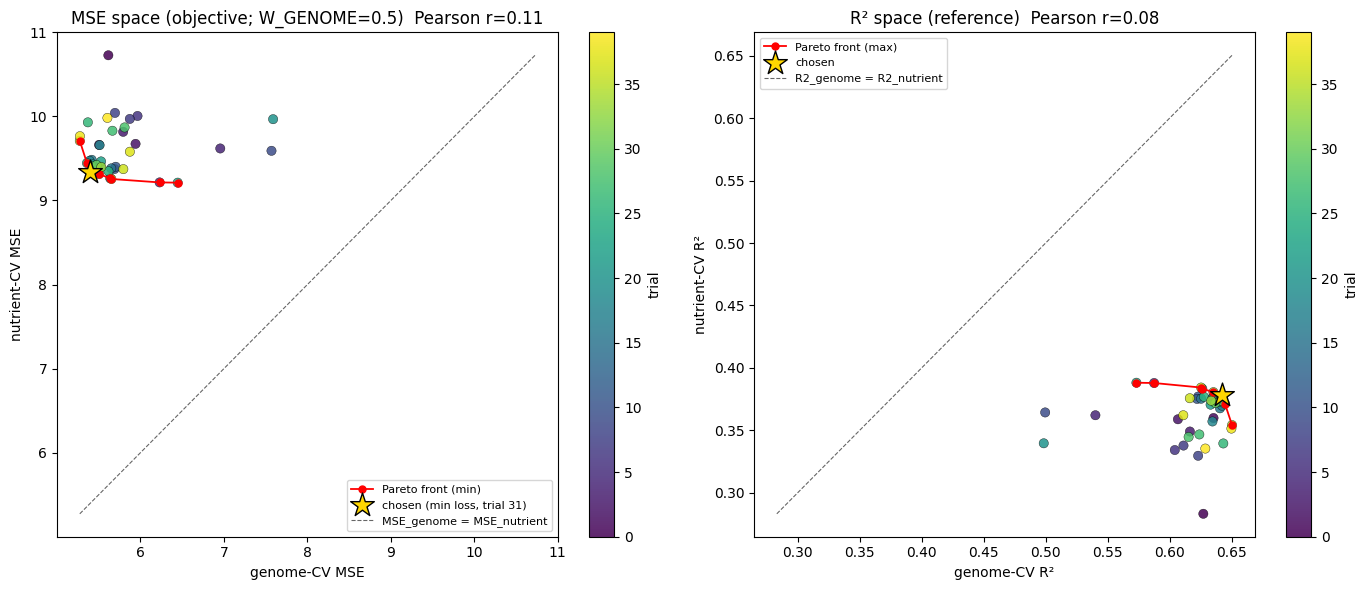

       trial  mse_genome  mse_nutrient    loss  r2_genome  r2_nutrient
count  40.00      40.000        40.000  40.000     40.000       40.000
mean   19.50       5.755         9.588   7.672      0.619        0.362
std    11.69       0.531         0.307   0.321      0.035        0.021
min     0.00       5.273         9.212   7.370      0.498        0.283
25%     9.75       5.464         9.377   7.451      0.616        0.351
50%    19.50       5.616         9.468   7.542      0.627        0.370
75%    29.25       5.799         9.778   7.805      0.637        0.376
max    39.00       7.589        10.727   8.778      0.650        0.388

MSE Pareto-optimal trials: [5, 19, 23, 24, 31, 32, 34, 35]
Chosen (min loss) trial 31: MSE g=5.396/n=9.344, R2 g=0.642/n=0.378


In [ ]:
# =============================================================================
# Step 3.1b — Pareto diagnostic in MSE space (and R2 for reference)
#   The objective minimises W_GENOME*MSE_genome + (1-W_GENOME)*MSE_nutrient, so the
#   relevant front is in MSE space (lower-left = better). Negative mse_genome-vs-
#   mse_nutrient correlation => a real tradeoff. Uses stored per-trial metrics
#   (r2/mse per axis) if present, else recomputes combined_cv_metrics.
# =============================================================================
from scipy.stats import pearsonr, spearmanr

RECOMPUTE_IF_MISSING = True
W = W_GENOME if "W_GENOME" in dir() else 0.5
_keys = ("r2_genome", "r2_nutrient", "mse_genome", "mse_nutrient")

assert "study" in dir(), "Run Step 3.1 first (the Optuna `study` must be in memory)."

_missing = [t for t in study.trials
            if t.state == optuna.trial.TrialState.COMPLETE and any(k not in t.user_attrs for k in _keys)]
if _missing and RECOMPUTE_IF_MISSING:
    logger.info(f"{len(_missing)} trials lack stored metrics — recomputing combined_cv_metrics "
                f"(~{len(_missing)} x {2 * OPTUNA_FOLDS} fits); re-run Step 3.1 once to avoid this next time.")

rows = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue
    if all(k in t.user_attrs for k in _keys):
        mm = {k: t.user_attrs[k] for k in _keys}
    elif RECOMPUTE_IF_MISSING:
        mm = combined_cv_metrics(active_cols, t.params, n_folds=OPTUNA_FOLDS, row_subsample=OPTUNA_ROW_SUBSAMPLE)
    else:
        continue
    mm["trial"] = t.number
    rows.append(mm)

pareto_df = pd.DataFrame(rows).sort_values("trial").reset_index(drop=True)
pareto_df["loss"] = W * pareto_df.mse_genome + (1 - W) * pareto_df.mse_nutrient
pareto_df.to_csv(os.path.join(OUTPUT_DIR, "optuna_pareto_trials.csv"), index=False)
chosen = pareto_df.loc[pareto_df.loss.idxmin()]

# Tradeoff signal: correlation of the two axes across trials (MSE space is the relevant one)
pr_mse = pearsonr(pareto_df.mse_genome, pareto_df.mse_nutrient)[0]
pr_r2 = pearsonr(pareto_df.r2_genome, pareto_df.r2_nutrient)[0]
logger.info(f"Trials: {len(pareto_df)} | mse_genome vs mse_nutrient: Pearson r={pr_mse:.3f} "
            f"(Spearman={spearmanr(pareto_df.mse_genome, pareto_df.mse_nutrient).correlation:.3f})")
logger.info(f"  (R2 space for reference: Pearson r={pr_r2:.3f})")
if pr_mse < -0.2:
    logger.info("  => NEGATIVE: real tradeoff (lowering one axis MSE raises the other); W_GENOME matters.")
elif pareto_df.mse_genome.std() < 1e-3:
    logger.info("  => genome MSE ~ constant across trials; weighting barely moves it.")
else:
    logger.info("  => axes co-move / weak tradeoff; objective choice is low-stakes.")
logger.info(f"  chosen trial {int(chosen.trial)}: MSE genome={chosen.mse_genome:.3f} / "
            f"nutrient={chosen.mse_nutrient:.3f}; R2 genome={chosen.r2_genome:.3f} / nutrient={chosen.r2_nutrient:.3f}")


def _front(df, xcol, ycol, maximize):
    """Non-dominated rows. maximize=True -> upper-right optimal; False -> lower-left optimal.
    Row i is dropped iff some other row dominates it (>=/<= on both, strictly on one)."""
    p = df[[xcol, ycol]].values
    nd = np.ones(len(p), bool)
    for i in range(len(p)):
        if maximize:
            dominated = np.any((p[:, 0] >= p[i, 0]) & (p[:, 1] >= p[i, 1]) &
                               ((p[:, 0] > p[i, 0]) | (p[:, 1] > p[i, 1])))
        else:
            dominated = np.any((p[:, 0] <= p[i, 0]) & (p[:, 1] <= p[i, 1]) &
                               ((p[:, 0] < p[i, 0]) | (p[:, 1] < p[i, 1])))
        nd[i] = not dominated
    return df[nd]


fig, (axM, axR) = plt.subplots(1, 2, figsize=(14, 6))

# Left: MSE space (lower-left is better) — the optimised front
fM = _front(pareto_df, "mse_genome", "mse_nutrient", maximize=False).sort_values("mse_genome")
scM = axM.scatter(pareto_df.mse_genome, pareto_df.mse_nutrient, c=pareto_df.trial,
                  cmap="viridis", s=45, alpha=0.85, edgecolor="k", linewidth=0.3)
axM.plot(fM.mse_genome, fM.mse_nutrient, "r-o", lw=1.3, ms=5, label="Pareto front (min)")
axM.scatter([chosen.mse_genome], [chosen.mse_nutrient], marker="*", s=320, color="gold",
            edgecolor="k", zorder=5, label=f"chosen (min loss, trial {int(chosen.trial)})")
loM = min(pareto_df.mse_genome.min(), pareto_df.mse_nutrient.min())
hiM = max(pareto_df.mse_genome.max(), pareto_df.mse_nutrient.max())
axM.plot([loM, hiM], [loM, hiM], "k--", lw=0.8, alpha=0.6, label="MSE_genome = MSE_nutrient")
axM.set_xlabel("genome-CV MSE"); axM.set_ylabel("nutrient-CV MSE")
axM.set_title(f"MSE space (objective; W_GENOME={W})  Pearson r={pr_mse:.2f}")
plt.colorbar(scM, ax=axM, label="trial"); axM.legend(loc="best", fontsize=8)

# Right: R2 space for reference (upper-right is better)
fR = _front(pareto_df, "r2_genome", "r2_nutrient", maximize=True).sort_values("r2_genome")
scR = axR.scatter(pareto_df.r2_genome, pareto_df.r2_nutrient, c=pareto_df.trial,
                  cmap="viridis", s=45, alpha=0.85, edgecolor="k", linewidth=0.3)
axR.plot(fR.r2_genome, fR.r2_nutrient, "r-o", lw=1.3, ms=5, label="Pareto front (max)")
axR.scatter([chosen.r2_genome], [chosen.r2_nutrient], marker="*", s=320, color="gold",
            edgecolor="k", zorder=5, label="chosen")
loR = min(pareto_df.r2_genome.min(), pareto_df.r2_nutrient.min())
hiR = max(pareto_df.r2_genome.max(), pareto_df.r2_nutrient.max())
axR.plot([loR, hiR], [loR, hiR], "k--", lw=0.8, alpha=0.6, label="R2_genome = R2_nutrient")
axR.set_xlabel("genome-CV R²"); axR.set_ylabel("nutrient-CV R²")
axR.set_title(f"R² space (reference)  Pearson r={pr_r2:.2f}")
plt.colorbar(scR, ax=axR, label="trial"); axR.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "optuna_pareto_diagnostic.png"), dpi=200)
plt.show()

print(pareto_df[["trial", "mse_genome", "mse_nutrient", "loss", "r2_genome", "r2_nutrient"]]
      .describe().round(3).to_string())
print(f"\nMSE Pareto-optimal trials: {sorted(fM.trial.tolist())}")
print(f"Chosen (min loss) trial {int(chosen.trial)}: "
      f"MSE g={chosen.mse_genome:.3f}/n={chosen.mse_nutrient:.3f}, "
      f"R2 g={chosen.r2_genome:.3f}/n={chosen.r2_nutrient:.3f}")

## Step 3.2 \u2014 Final robust model: dual evaluation + baseline comparison

Train the robust model (union features + worst-case-tuned params) on the pool and evaluate on both held-out
blocks. Compare against a **genome-only** baseline (genome-axis features, default params).

                                             genome_test  nutrient_test  both_test  worst_case
robust (both-axis feats + worst-case tuned)       0.6230         0.4086     0.2547      0.4086
genome-only (genome feats + default)              0.3967         0.0611     0.0776      0.0611


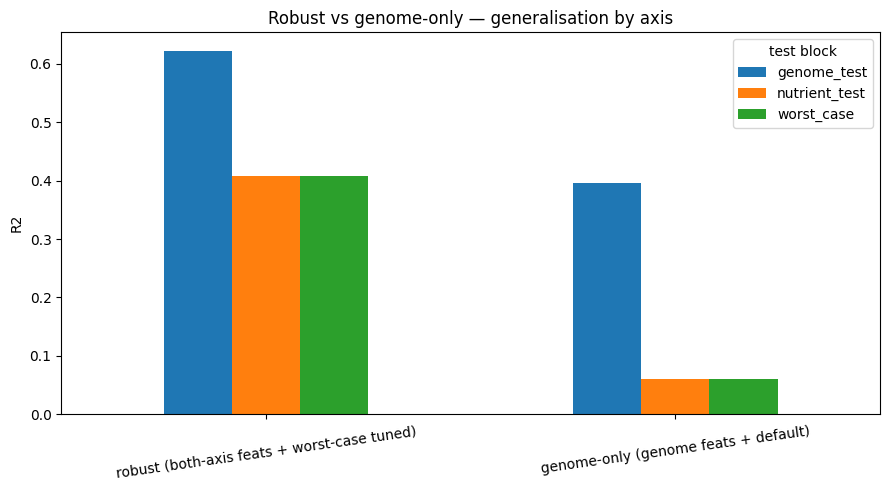

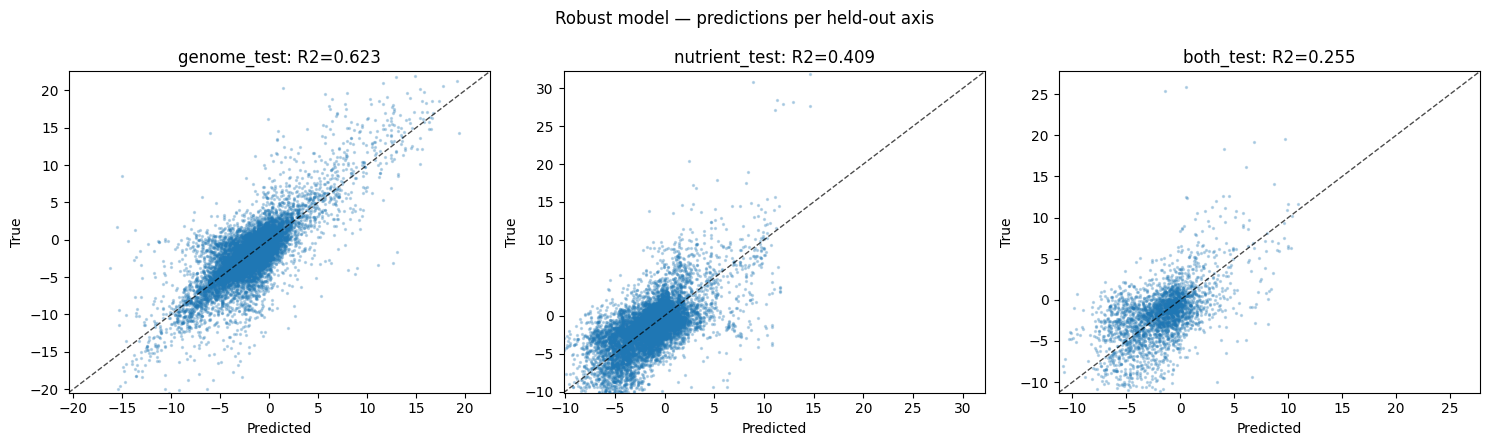

In [ ]:
# =============================================================================
# Step 3.2 \u2014 Train robust model, evaluate, compare to genome-only baseline
# =============================================================================
# Robust model
robust = xgb.XGBRegressor(**BASE_PARAMS, **best_params)
robust.fit(X_pool[active_cols], y_pool)
robust.get_booster().save_model(os.path.join(OUTPUT_DIR, "robust_model.json"))
rob_scores = eval_blocks(robust, active_cols)
r2_tracker["3.2_robust"] = rob_scores

# Genome-only baseline: features important on the genome axis only, default params
genome_feats = nutrient_cols + sorted(go_genome)
base = xgb.XGBRegressor(**BASE_PARAMS, n_estimators=400)
base.fit(X_pool[genome_feats], y_pool)
base_scores = eval_blocks(base, genome_feats)
r2_tracker["3.2_genome_only"] = base_scores
del base; gc.collect()

cmp = pd.DataFrame({
    "robust (both-axis feats + worst-case tuned)": rob_scores,
    "genome-only (genome feats + default)": base_scores,
}).T[["genome_test", "nutrient_test", "both_test", "worst_case"]]
cmp.to_csv(os.path.join(OUTPUT_DIR, "robust_model_comparison.csv"))
print(cmp.round(4).to_string())

# Bar chart
ax = cmp[["genome_test", "nutrient_test", "worst_case"]].plot(
    kind="bar", figsize=(9, 5), rot=8)
ax.set_ylabel("R2"); ax.set_title("Robust vs genome-only \u2014 generalisation by axis")
ax.legend(title="test block"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robust_model_comparison.png"), dpi=200)
plt.show()

# Per-block prediction scatters for the robust model
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, idx) in zip(axes, [("genome_test", genome_test_idx),
                                  ("nutrient_test", nutrient_test_idx), ("both_test", both_test_idx)]):
    yt = y.iloc[idx]; yp = robust.predict(X.iloc[idx][active_cols])
    ax.scatter(yp, yt, s=2, alpha=0.25)
    lo, hi = yt.min() + 10, yt.max() - 10
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.7); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{name}: R2={rob_scores[name]:.3f}")
plt.suptitle("Robust model \u2014 predictions per held-out axis"); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robust_predictions.png"), dpi=200)
plt.show()

## Step 4 — SHAP feature attribution

The final model is retrained on **all data** (union features + worst-case-tuned params) and explained with
`shap.TreeExplainer` (exact for XGBoost). Because the model generalises much better to unseen genomes
(R²≈0.62, at the replicate ceiling) than to unseen nutrient conditions (R²≈0.40), SHAP trust is
**axis-dependent**:

- **GO / gene SHAP rankings are trustworthy** — the genome axis is essentially fully learned.
- **Nutrient and gene×nutrient SHAP** should be read as a **lower bound** on importance: the model
  under-learned the nutrient axis, so those attributions are likely understated. *Low nutrient SHAP does
  **not** mean nutrients are biologically unimportant.*

**Step 4.1** quantifies this with a per-axis generalisation check (Spearman ρ of mean|SHAP| between the
pool and each held-out block — expect ρ_genome ≫ ρ_nutrient). **Step 4.2** retrains on all data and computes
final SHAP. **Step 4.3** exports the SHAP matrix + per-row metadata and summary/dependence plots.
**Step 4.4** checks bootstrap stability of the importances.

In [ ]:
# =============================================================================
# Step 4.1 — Pool SHAP + per-axis generalization check
#   Spearman rho of mean|SHAP| between the pool and each held-out block quantifies
#   how well attributions transfer to unseen genomes vs unseen nutrient conditions.
# =============================================================================
import shap
from scipy.stats import spearmanr

SHAP_BATCH_SIZE = 5000
SHAP_GENERALIZATION_THRESHOLD = 0.85

# best_params may not be in scope if Step 3.1 wasn't re-run this session
if "best_params" not in dir():
    with open(os.path.join(OUTPUT_DIR, "robust_best_params.json")) as f:
        best_params = json.load(f)

# Pool-trained model: reuse `robust` from Step 3.2 if present, else refit on the pool
try:
    pool_model = robust
except NameError:
    pool_model = xgb.XGBRegressor(**BASE_PARAMS, **best_params)
    pool_model.fit(X_pool[active_cols], y_pool)

pool_model.set_params(device="cpu")   # CPU pred_contribs -> bounded memory
explainer = shap.TreeExplainer(pool_model)


def compute_shap_batched(expl, X_data, batch_size=SHAP_BATCH_SIZE):
    """SHAP values in row batches to manage memory; returns an (n, n_feat) array."""
    parts = []
    n = len(X_data)
    for start in range(0, n, batch_size):
        parts.append(expl.shap_values(X_data.iloc[start:start + batch_size]))
        gc.collect()
    return np.vstack(parts)


blocks = {
    "pool":          X_pool[active_cols],
    "genome_test":   X.iloc[genome_test_idx][active_cols],
    "nutrient_test": X.iloc[nutrient_test_idx][active_cols],
}
mean_abs = {}
for name, Xb in blocks.items():
    logger.info(f"SHAP on {name} ({len(Xb)} rows)...")
    sv = compute_shap_batched(explainer, Xb)
    mean_abs[name] = pd.Series(np.abs(sv).mean(axis=0), index=active_cols)

# Per-axis generalization: rank correlation of mean|SHAP| over GO features
rho_genome,   p_g = spearmanr(mean_abs["pool"][go_cols], mean_abs["genome_test"][go_cols])
rho_nutrient, p_n = spearmanr(mean_abs["pool"][go_cols], mean_abs["nutrient_test"][go_cols])
logger.info("SHAP generalization (GO mean|SHAP| Spearman rho vs pool):")
logger.info(f"  pool vs genome_test   = {rho_genome:.4f} (p={p_g:.1e})")
logger.info(f"  pool vs nutrient_test = {rho_nutrient:.4f} (p={p_n:.1e})")

shap_generalizes = rho_genome > SHAP_GENERALIZATION_THRESHOLD
logger.info(f"  genome-axis SHAP generalizes: {'YES' if shap_generalizes else 'NO'} "
            f"(threshold {SHAP_GENERALIZATION_THRESHOLD}); nutrient-axis rho is the caution metric")

pd.DataFrame(mean_abs).to_csv(os.path.join(OUTPUT_DIR, "robust_shap_generalization.csv"))
r2_tracker["4.1_shap_generalization"] = {"rho_genome": float(rho_genome), "rho_nutrient": float(rho_nutrient)}

2026-06-08 17:44:27,635 — INFO — SHAP on pool (42886 rows)...
2026-06-08 17:44:49,224 — INFO — SHAP on genome_test (11696 rows)...
2026-06-08 17:44:55,293 — INFO — SHAP on nutrient_test (10433 rows)...
2026-06-08 17:45:00,858 — INFO — SHAP generalization (GO mean|SHAP| Spearman rho vs pool):
2026-06-08 17:45:00,859 — INFO —   pool vs genome_test   = 0.9551 (p=1.3e-117)
2026-06-08 17:45:00,860 — INFO —   pool vs nutrient_test = 0.9938 (p=3.6e-211)
2026-06-08 17:45:00,860 — INFO —   genome-axis SHAP generalizes: YES (threshold 0.85); nutrient-axis rho is the caution metric


In [ ]:
# =============================================================================
# Step 4.2 — Retrain on ALL data & compute final SHAP
# =============================================================================
final_model_all = xgb.XGBRegressor(**BASE_PARAMS, **best_params)
final_model_all.fit(X[active_cols], y)
final_model_all.get_booster().save_model(os.path.join(OUTPUT_DIR, "robust_model_all_data.json"))
logger.info("All-data robust model saved.")

final_model_all.set_params(device="cpu")   # CPU pred_contribs -> bounded memory for all-row SHAP
explainer_all = shap.TreeExplainer(final_model_all)
logger.info(f"Computing final SHAP on all data ({len(X)} rows, {len(active_cols)} features)...")
shap_final = compute_shap_batched(explainer_all, X[active_cols])
logger.info(f"Final SHAP shape: {shap_final.shape}")

2026-06-08 17:45:06,723 — INFO — All-data robust model saved.
2026-06-08 17:45:06,852 — INFO — Computing final SHAP on all data (67913 rows, 243 features)...
2026-06-08 17:45:48,487 — INFO — Final SHAP shape: (67913, 243)


2026-06-08 17:45:49,212 — INFO — Exported shap_values.parquet (67913, 243) + shap_row_metadata.parquet


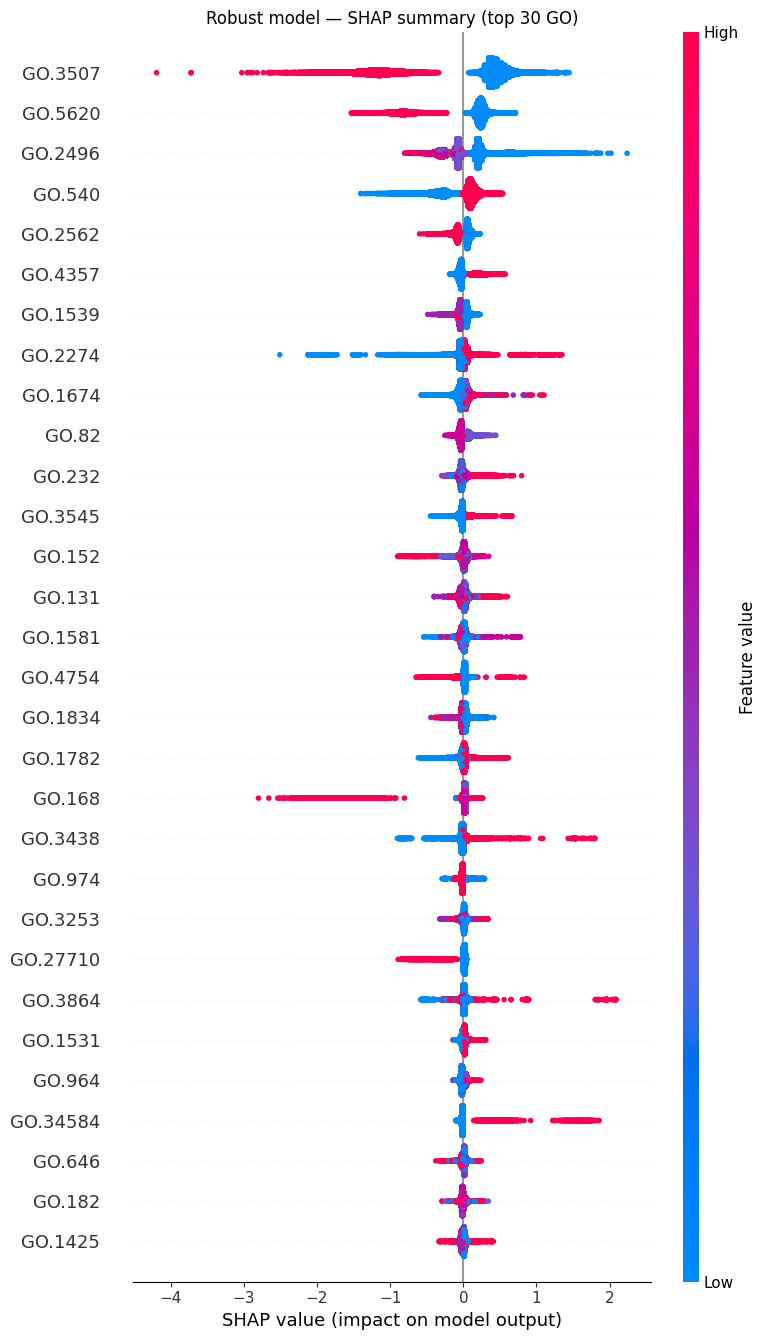

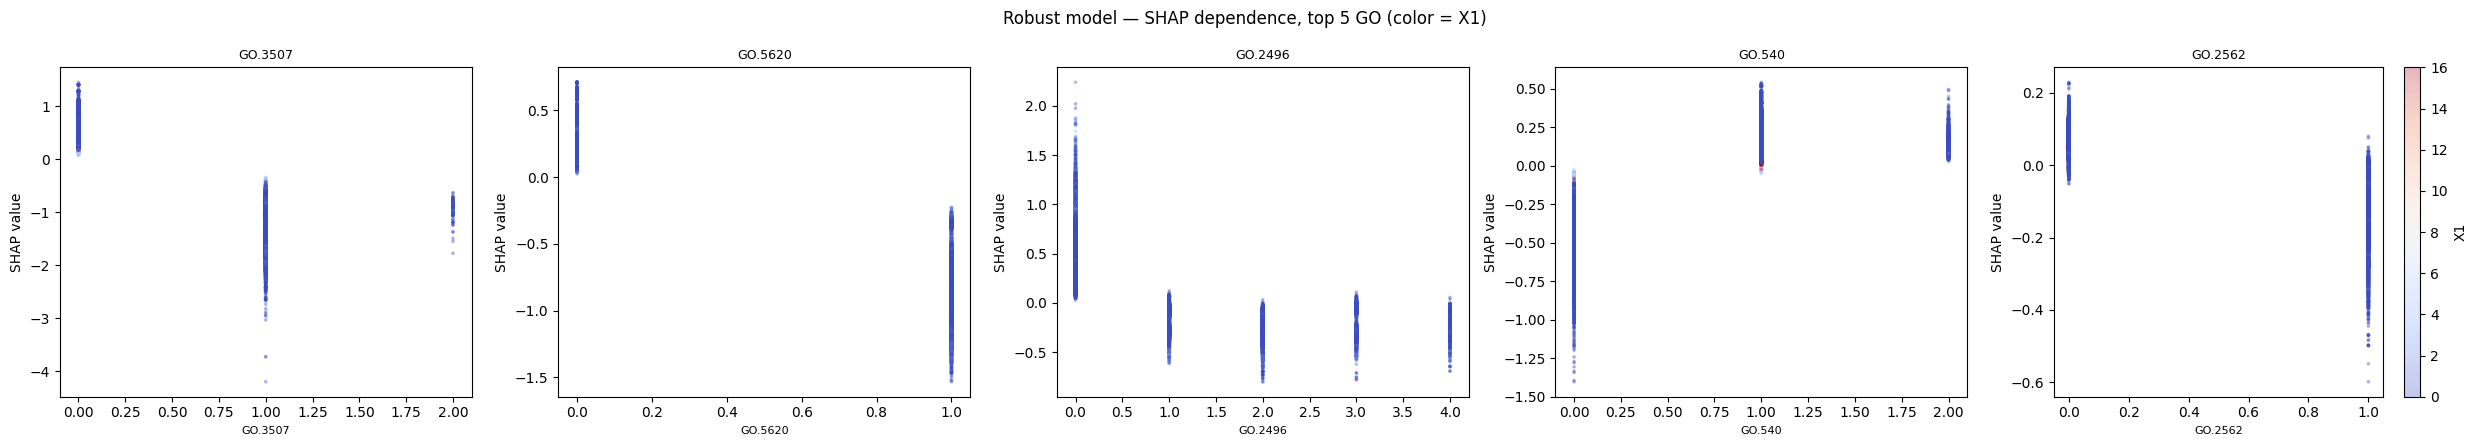

2026-06-08 17:46:58,465 — INFO — SHAP summary + dependence plots saved.


In [ ]:
# =============================================================================
# Step 4.3 — Export SHAP matrix, row metadata, and summary/dependence plots
# =============================================================================
shap_df = pd.DataFrame(shap_final, columns=active_cols, index=X.index).astype(np.float32)
shap_df.to_parquet(os.path.join(OUTPUT_DIR, "shap_values.parquet"))

# Per-row block label from the four positional index arrays
block = np.empty(len(X), dtype=object)
block[pool_idx] = "pool"
block[genome_test_idx] = "genome_test"
block[nutrient_test_idx] = "nutrient_test"
block[both_test_idx] = "both_test"

metadata = pd.DataFrame({
    "species_id": species_arr,
    "condition_id": condition_arr,
    "block": block,
}, index=X.index)
for nc in nutrient_cols:
    metadata[nc] = X[nc].values
metadata.to_parquet(os.path.join(OUTPUT_DIR, "shap_row_metadata.parquet"))
logger.info(f"Exported shap_values.parquet {shap_df.shape} + shap_row_metadata.parquet")

# Beeswarm summary — top 30 GO by mean|SHAP|
top30 = shap_df[go_cols].abs().mean().nlargest(30).index.tolist()
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_df[top30].values, X[top30], feature_names=top30, show=False, max_display=30)
plt.title("Robust model — SHAP summary (top 30 GO)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robust_shap_summary_top30.pdf"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "robust_shap_summary_top30.svg"), bbox_inches="tight")
plt.show()

# Dependence plots — top 5 GO, colored by the first nutrient
top5 = top30[:5]; nut0 = nutrient_cols[0]
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for ax_i, g in zip(axes, top5):
    sc = ax_i.scatter(X[g].values, shap_df[g].values, c=X[nut0].values,
                      cmap="coolwarm", alpha=0.3, s=3, rasterized=True)
    ax_i.set_xlabel(g, fontsize=8); ax_i.set_ylabel("SHAP value"); ax_i.set_title(g, fontsize=9)
plt.colorbar(sc, ax=axes[-1], label=nut0)
plt.suptitle(f"Robust model — SHAP dependence, top 5 GO (color = {nut0})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robust_shap_dependence_top5.pdf"), bbox_inches="tight", dpi=300)
plt.savefig(os.path.join(OUTPUT_DIR, "robust_shap_dependence_top5.svg"), bbox_inches="tight")
plt.show()
logger.info("SHAP summary + dependence plots saved.")

Bootstrap SHAP:   0%|          | 0/30 [00:00<?, ?it/s]

2026-06-08 17:48:34,111 — INFO — Split-half Spearman median=1.000 [p10=1.000, p90=1.000]


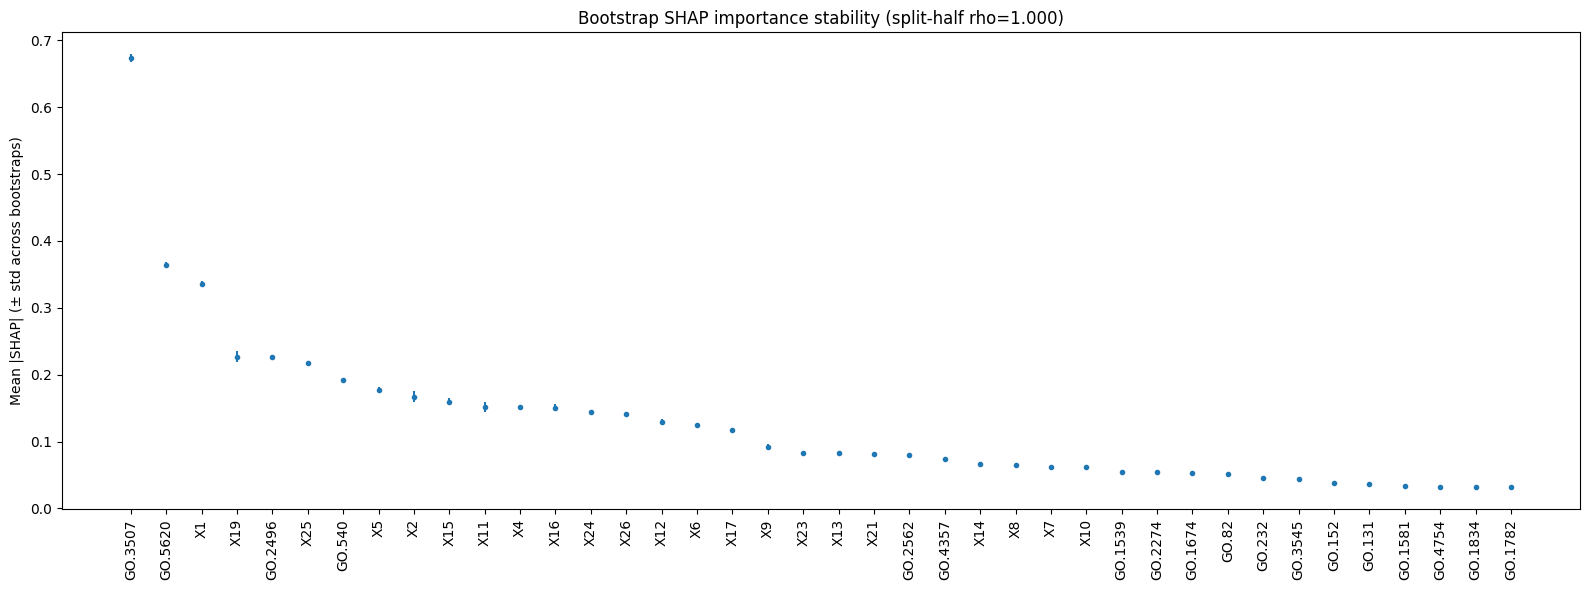

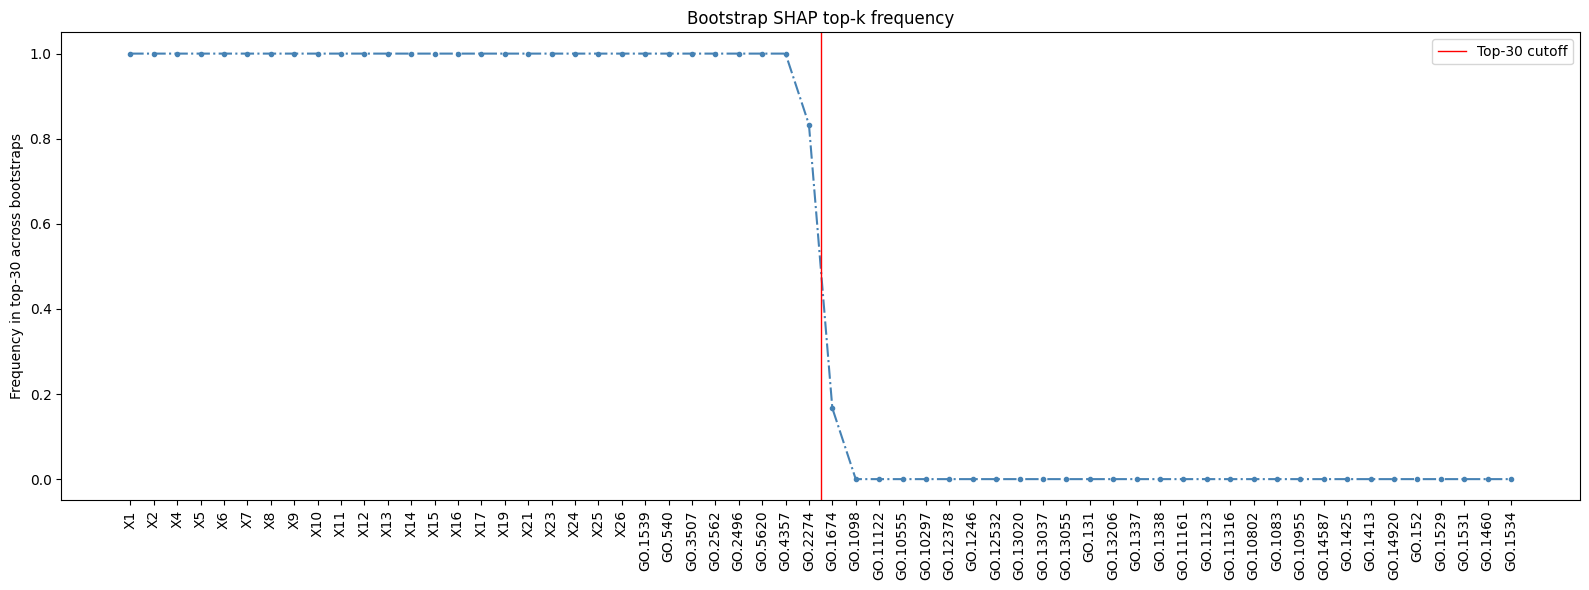

In [ ]:
# =============================================================================
# Step 4.4 — Bootstrap SHAP importance stability (fixed all-data model)
# =============================================================================
N_BOOT = 30
SHAP_N = 5000
TOP_K = 30

X_all = X[active_cols]
n_all = len(X_all)
boot_imps = []
for s in tqdm(range(123, 123 + N_BOOT), desc="Bootstrap SHAP"):
    rng = np.random.default_rng(s)
    idx = rng.choice(n_all, size=SHAP_N, replace=True)
    sv = explainer_all.shap_values(X_all.iloc[idx])
    boot_imps.append(np.abs(sv).mean(axis=0))
    gc.collect()

imp_mat = pd.DataFrame(boot_imps, columns=active_cols)
imp_mean = imp_mat.mean(axis=0).sort_values(ascending=False)
imp_std = imp_mat.std(axis=0).loc[imp_mean.index]

# Top-k frequency across bootstraps
topk_freq = (imp_mat.apply(lambda r: r.nlargest(TOP_K).index, axis=1)
             .explode().value_counts().div(N_BOOT)
             .reindex(active_cols, fill_value=0.0).sort_values(ascending=False))

# Split-half Spearman rank stability of mean|SHAP|
rng = np.random.default_rng(999)
half = N_BOOT // 2
split = []
for _ in range(50):
    p = rng.permutation(N_BOOT)
    a = imp_mat.iloc[p[:half]].mean().rank(ascending=False)
    b = imp_mat.iloc[p[half:]].mean().rank(ascending=False)
    split.append(spearmanr(a, b).correlation)
split = np.array(split, float)
logger.info(f"Split-half Spearman median={np.nanmedian(split):.3f} "
            f"[p10={np.nanpercentile(split, 10):.3f}, p90={np.nanpercentile(split, 90):.3f}]")
r2_tracker["4.4_shap_stability"] = {"split_half_spearman_median": float(np.nanmedian(split))}
topk_freq.to_csv(os.path.join(OUTPUT_DIR, "robust_shap_topk_frequency.csv"))

# Plot: mean|SHAP| with std error bars (top 40 for legibility)
top40 = imp_mean.head(40)
fig, ax = plt.subplots(figsize=(16, 6))
ax.errorbar(x=top40.index, y=top40.values, yerr=imp_std.loc[top40.index].values, fmt='o', ms=3)
plt.xticks(rotation=90); plt.ylabel("Mean |SHAP| (± std across bootstraps)")
plt.title(f"Bootstrap SHAP importance stability (split-half rho={np.nanmedian(split):.3f})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robust_bootstrap_shap_importance_stability.pdf"), bbox_inches="tight", dpi=150)
plt.show()

# Plot: top-k frequency
fig, ax = plt.subplots(figsize=(16, 6))
plt.plot(topk_freq.head(60).values, '-.o', color="steelblue", ms=3)
plt.xticks(range(60), topk_freq.head(60).index, rotation=90)
plt.axvline(TOP_K - 0.5, color='red', lw=1, label=f"Top-{TOP_K} cutoff")
plt.legend(); plt.ylabel(f"Frequency in top-{TOP_K} across bootstraps")
plt.title("Bootstrap SHAP top-k frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "robust_bootstrap_shap_topk_frequency.pdf"), bbox_inches="tight", dpi=150)
plt.show()

## Step 5 — Phylogenetic & GWAS validation of the SHAP genes

Two independent, phylogeny-aware checks that the model's SHAP-important genes reflect real biology:

- **5.1–5.2 GWAS vs SHAP.** A phylogeny-aware GWAS (pyseer LMM, kinship from the strain tree) tests each
  gene's association with mean suppression while controlling for population structure. We then ask whether
  the SHAP-selected genes are **enriched among GWAS hits**, whether |SHAP| tracks GWAS signal, and whether
  effect *directions* agree. The tree kinship is computed here with `Bio.Phylo` (no external
  `phylogeny_distance.py`); only the pyseer LMM itself runs via the `pyseer_env` tool (guarded by `RUN_PYSEER`).
- **5.3–5.4 Homoplasy.** Per-gene Fitch-parsimony homoplasy on the same tree vs a frequency-preserving null →
  are important genes scattered across the tree (candidate functional) or clade-clumped? Compared across
  SHAP-selected / GWAS-significant / background gene groups.

**Caveats.** Presence/absence is used (the model trains on copy number); the external **sequence tree** is
the independent reference (a gene-content tree would be circular); this grades, it does not prove.

In [ ]:
# =============================================================================
# Step 5.1 — Phylogeny-aware GWAS (pyseer LMM) — self-contained
#   phenotype + genotype + tree var-covar kinship (computed here with Bio.Phylo,
#   NO external phylogeny_distance.py / dendropy), then pyseer LMM.
#   Guarded: reuses existing pyseer_output/ unless RUN_PYSEER=True.
#   The pyseer *binary* still comes from pyseer_env (a tool, not a script).
# =============================================================================
import subprocess
from Bio import Phylo

PYSEER = "/home/rl/mambaforge/envs/pyseer_env/bin/pyseer"
PYS_OUT = "pyseer_output"; os.makedirs(PYS_OUT, exist_ok=True)
TREE = "strain_tree_converted_to_strain.nwk"
RUN_PYSEER = not os.path.exists(f"{PYS_OUT}/pyseer_gwas.tsv")   # set True to force a fresh pyseer run


def tree_kinship_lmm(tree_path):
    """Var-covar matrix C[i,j] = root-to-MRCA distance (identical to phylogeny_distance.py --lmm)."""
    tr = Phylo.read(tree_path, "newick")
    tips = tr.get_terminals(); names = [t.name for t in tips]; idx = {t.name: k for k, t in enumerate(tips)}
    C = np.zeros((len(names), len(names)))
    for clade in tr.find_clades():
        bl = clade.branch_length or 0.0
        if not bl:
            continue
        js = [idx[l.name] for l in clade.get_terminals()]
        v = np.zeros(len(names)); v[js] = 1.0
        C += bl * np.outer(v, v)
    return pd.DataFrame(C, index=names, columns=names)


if RUN_PYSEER:
    _tips = [t.name for t in Phylo.read(TREE, "newick").get_terminals()]
    # phenotype: per-strain mean suppression (one value per tip)
    _lp = pd.read_csv("./merged_accumulated_results_2024-03-19_series1_step8.csv", usecols=["strain", "z_score"])
    _lp["strain"] = _lp["strain"].astype(str)
    _ph = _lp.groupby("strain")["z_score"].mean().reindex(_tips).dropna()
    _ph.index.name = "samples"; _ph.name = "mean_z"; _ph.to_csv(f"{PYS_OUT}/pheno.tsv", sep="\t")
    # genotype: binarized panX gene content, GO x strains, restricted to tips, invariant dropped
    _ft = pd.read_csv("./panx_and_strains_table_final_post_filtering_strain_names.csv", index_col=0)
    _ft.index = _ft.index.astype(str)
    _st = [s for s in _tips if s in _ft.index and s in _ph.index]
    _G = (_ft.loc[_st] > 0).astype("int8").T
    _G = _G.loc[~((_G.sum(1) == 0) | (_G.sum(1) == len(_st)))]; _G.index.name = "Gene"
    _G.to_csv(f"{PYS_OUT}/genotype.Rtab", sep="\t")
    # tree kinship (self-contained; matches phylogeny_distance.py --lmm to float precision)
    tree_kinship_lmm(TREE).to_csv(f"{PYS_OUT}/phylo_K.tsv", sep="\t")
    # pyseer LMM (external tool in pyseer_env)
    _cmd = (f"{PYSEER} --lmm --phenotypes {PYS_OUT}/pheno.tsv --pres {PYS_OUT}/genotype.Rtab "
            f"--similarity {PYS_OUT}/phylo_K.tsv --output-patterns {PYS_OUT}/patterns.txt --cpu 8")
    logger.info("running pyseer LMM ...")
    _r = subprocess.run(_cmd, shell=True, capture_output=True, text=True)
    if _r.returncode != 0:
        raise RuntimeError(f"pyseer failed:\n{_r.stderr[-1500:]}")
    open(f"{PYS_OUT}/pyseer_gwas.tsv", "w").write(_r.stdout)
    logger.info(f"pyseer GWAS complete: {sum(1 for _ in open(f'{PYS_OUT}/pyseer_gwas.tsv')) - 1} GO tested")
else:
    logger.info(f"Reusing existing {PYS_OUT}/pyseer_gwas.tsv (set RUN_PYSEER=True to re-run pyseer)")

In [ ]:
# =============================================================================
# Step 5.2 — GWAS vs SHAP: enrichment, rank correlation, effect-direction, volcano
# =============================================================================
from scipy.stats import fisher_exact, spearmanr

gw = pd.read_csv(f"{PYS_OUT}/pyseer_gwas.tsv", sep="\t").rename(columns={"variant": "GO"}).set_index("GO")
gw["lrt-pvalue"] = pd.to_numeric(gw["lrt-pvalue"], errors="coerce")
gw["beta"] = pd.to_numeric(gw["beta"], errors="coerce")
gw = gw.dropna(subset=["lrt-pvalue"])
gw["neglog10p"] = -np.log10(gw["lrt-pvalue"].clip(lower=1e-300))
n_patterns = len(set(open(f"{PYS_OUT}/patterns.txt").read().split()))
thresh = 0.05 / n_patterns
is_sig = (gw["lrt-pvalue"] < thresh).values

go_cols_sel = json.load(open(os.path.join(OUTPUT_DIR, "robust_feature_list.json")))["go_cols"]
mean_abs_shap = pd.read_parquet(os.path.join(OUTPUT_DIR, "shap_values.parquet"))[go_cols_sel].abs().mean()
sel = [g for g in go_cols_sel if g in gw.index]
is_sel = gw.index.isin(go_cols_sel)

# (1) Fisher enrichment: SHAP-selected among GWAS-significant
a = int((is_sel & is_sig).sum()); b = int((is_sel & ~is_sig).sum())
c = int((~is_sel & is_sig).sum()); d = int((~is_sel & ~is_sig).sum())
odds, fp = fisher_exact([[a, b], [c, d]], alternative="greater")
# (2) within selected: |SHAP| vs GWAS signal
rho, rp = spearmanr(mean_abs_shap.loc[sel], gw.loc[sel, "neglog10p"])
# (3) effect-direction agreement: pyseer beta vs SHAP copy-direction (per gene)
_meta = pd.read_parquet(os.path.join(OUTPUT_DIR, "shap_row_metadata.parquet"))
_sd = pd.read_parquet(os.path.join(OUTPUT_DIR, "shap_values.parquet"))
_ft = pd.read_csv("./panx_and_strains_table_final_post_filtering_strain_names.csv", index_col=0)
_ft.index = _ft.index.astype(str)
_srow = _meta["species_id"].astype(str).values
_shap_by_strain = _sd[sel].groupby(_srow).mean()
_copy_by_strain = _ft.loc[_shap_by_strain.index, sel]
_ag = _tot = 0
for g in sel:
    _bj = gw.loc[g, "beta"]
    if not np.isfinite(_bj):
        continue
    _cc = np.corrcoef(_copy_by_strain[g].values, _shap_by_strain[g].values)[0, 1]
    if np.isfinite(_cc) and _cc != 0:
        _tot += 1; _ag += (np.sign(_bj) == np.sign(_cc))

logger.info(f"GWAS: {len(gw)} GO tested, {int(is_sig.sum())} significant (Bonferroni {thresh:.1e}, {n_patterns} patterns)")
logger.info(f"  SHAP-selected among GWAS-sig: {a}/{a+b} ({100*a/max(a+b,1):.1f}%) vs {c}/{c+d} others "
            f"({100*c/max(c+d,1):.1f}%) -> OR={odds:.2f}, Fisher p={fp:.2e}")
logger.info(f"  Spearman(mean|SHAP|, -log10 p) over selected GO: rho={rho:.3f} (p={rp:.2e})")
logger.info(f"  effect-sign agreement (pyseer beta vs SHAP copy-direction): {_ag}/{_tot} = {_ag/max(_tot,1):.2f}")
r2_tracker["5_gwas_vs_shap"] = {"enrichment_OR": float(odds), "fisher_p": float(fp),
                                "spearman_rho": float(rho), "effect_sign_agree": _ag / max(_tot, 1)}

comp = pd.DataFrame({"mean_abs_shap": mean_abs_shap.reindex(gw.index), "gwas_p": gw["lrt-pvalue"],
                     "gwas_beta": gw["beta"], "neglog10p": gw["neglog10p"],
                     "shap_selected": is_sel, "gwas_sig": is_sig}, index=gw.index)
comp.to_csv(os.path.join(OUTPUT_DIR, "pyseer_shap_comparison.csv"))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(gw["beta"], gw["neglog10p"], s=4, alpha=0.2, color="grey", label="all GO")
ax[0].scatter(gw.loc[sel, "beta"], gw.loc[sel, "neglog10p"], s=16, color="crimson", label="SHAP-selected")
ax[0].axhline(-np.log10(thresh), ls="--", color="k", lw=0.8, label="sig. threshold")
ax[0].set_xlabel("pyseer beta"); ax[0].set_ylabel("-log10 LMM p")
ax[0].set_title(f"GWAS volcano  (OR={odds:.1f}, Fisher p={fp:.1e})"); ax[0].legend(fontsize=8)
ax[1].scatter(mean_abs_shap.loc[sel], gw.loc[sel, "neglog10p"], s=16, alpha=0.6, color="#4C72B0")
ax[1].axhline(-np.log10(thresh), ls="--", color="k", lw=0.8)
ax[1].set_xlabel("mean|SHAP| (selected GO)"); ax[1].set_ylabel("-log10 LMM p")
ax[1].set_title(f"SHAP vs GWAS  (Spearman rho={rho:.2f})")
plt.tight_layout()
for ext in ("pdf", "svg", "png"):
    plt.savefig(os.path.join(OUTPUT_DIR, f"pyseer_shap_comparison.{ext}"), dpi=200, bbox_inches="tight")
plt.show()

In [4]:
# =============================================================================
# Step 5.3 — Per-gene phylogenetic signal (homoplasy) via Fitch parsimony
#   External sequence tree (independent reference); presence/absence; freq-preserving null.
# =============================================================================
import sys
from Bio import Phylo
sys.setrecursionlimit(100000)

TREE = "strain_tree_converted_to_strain.nwk"
HOMOPLASY_K = 50   # frequency-preserving tip-shuffle null replicates

ptree = Phylo.read(TREE, "newick")
ptips = [str(x.name) for x in ptree.get_terminals()]
_panx = pd.read_csv("./panx_and_strains_table_final_post_filtering_strain_names.csv", index_col=0)
_panx.index = _panx.index.astype(str)
Gp = (_panx > 0).astype("int8").T                        # GO x strains presence/absence
Gp.columns = Gp.columns.astype(str)
Gp = Gp[[t for t in ptips if t in Gp.columns]]           # restrict to tree tips
Gp = Gp.loc[~((Gp.sum(1) == 0) | (Gp.sum(1) == Gp.shape[1]))]   # drop invariant GO
genes_arr = Gp.index.to_numpy(); Mg = Gp.to_numpy().astype(np.int8)
name2col = {t: i for i, t in enumerate(Gp.columns)}
logger.info(f"Homoplasy: {Mg.shape[0]} variable GO x {Mg.shape[1]} strains (tree tips {len(ptips)})")


def fitch_changes(tipmask):
    """Vectorised Fitch down-pass: min presence/absence transitions per gene (all genes at once).
    Set states in uint8: 1={absent}, 2={present}, 3={absent,present}."""
    changes = np.zeros(Mg.shape[0], np.int32)
    def rec(cl):
        if cl.is_terminal():
            return tipmask[:, name2col[str(cl.name)]]
        it = iter(cl.clades); m = rec(next(it)).copy()
        for c in it:
            mm = rec(c); inter = m & mm; ch = inter == 0
            m = np.where(ch, m | mm, inter).astype(np.uint8); changes[ch] += 1
        return m
    rec(ptree.root); return changes


base_mask = np.where(Mg == 1, np.uint8(2), np.uint8(1))
obs = fitch_changes(base_mask)
_rng = np.random.default_rng(0); exp = np.zeros(Mg.shape[0])
for _ in range(HOMOPLASY_K):
    exp += fitch_changes(base_mask[:, _rng.permutation(Mg.shape[1])])
exp /= HOMOPLASY_K
ps = pd.DataFrame({"GO": genes_arr, "n_carriers": Mg.sum(1), "obs_changes": obs,
                   "exp_changes": exp.round(2),
                   "homoplasy_index": (obs / np.maximum(exp, 1e-9)).round(4)}).set_index("GO")
ps.to_csv(os.path.join(OUTPUT_DIR, "phylo_signal_per_gene.csv"))
logger.info(f"Homoplasy index: {len(ps)} genes, median {ps.homoplasy_index.median():.3f}")

/tmp/ipykernel_296089/2077906865.py:19: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  Gp = Gp.loc[~((Gp.sum(1) == 0) | (Gp.sum(1) == Gp.shape[1]))]   # drop invariant GO
/tmp/ipykernel_296089/2077906865.py:19: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  Gp = Gp.loc[~((Gp.sum(1) == 0) | (Gp.sum(1) == Gp.shape[1]))]   # drop invariant GO
2026-07-13 11:27:01,989 — INFO — Homoplasy: 58331 variable GO x 298 strains (tree tips 298)
2026-07-13 11:27:04,333 — INFO — Homoplasy index: 58331 genes, median 0.336


2026-07-13 11:27:04,498 — INFO — GWAS: 64 genome-wide-significant genes (Bonferroni 3.2e-06, 15571 patterns)
2026-07-13 11:27:04,671 — INFO — freq-adj homoplasy_pct medians — SHAP 0.857 (n=217), GWAS-only 0.830 (n=61), background 0.505
2026-07-13 11:27:04,677 — INFO —   MWU SHAP>background p=4.56e-55
2026-07-13 11:27:04,681 — INFO —   MWU GWAS>background p=9.08e-13 | SHAP vs GWAS (2-sided) p=1.40e-01


          n_carriers  obs_changes  homoplasy_index  homoplasy_pct  mean_abs_shap  gwas_nlp  gwas_sig
GO                                                                                                  
GO.3507           62            4            0.070          0.404          0.674     9.097      True
GO.5620           35            3            0.089          0.407          0.365     7.231      True
GO.2496          103           17            0.196          0.806          0.227     9.936      True
GO.540           233            6            0.100          0.524          0.192     4.308     False
GO.2562           99           12            0.145          0.683          0.080     1.796     False
GO.4357           44           10            0.241          0.810          0.074     3.644     False
GO.1539          141           12            0.122          0.609          0.055     3.839     False
GO.2274          109            2            0.023          0.139          0.054     4.783 

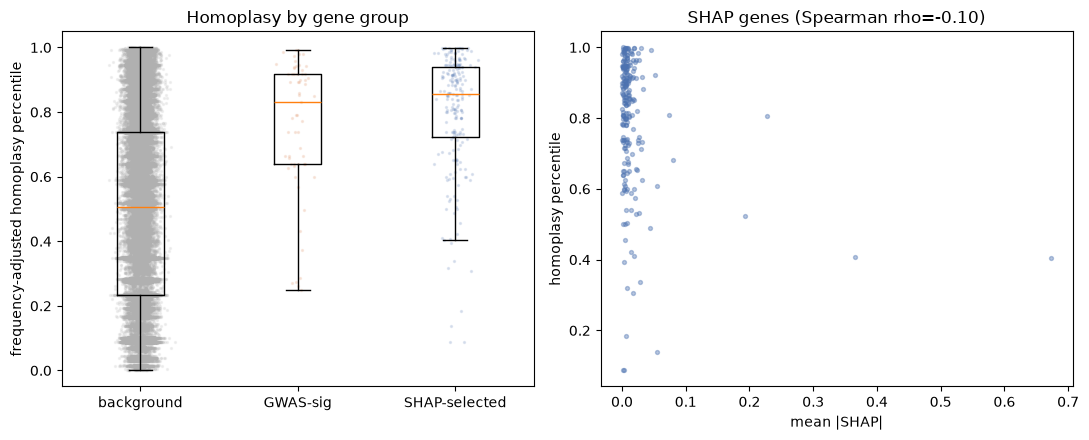

In [5]:
# =============================================================================
# Step 5.4 — Frequency-adjust, annotate (SHAP + GWAS), compare groups, plot
# =============================================================================
from scipy.stats import mannwhitneyu, spearmanr

# frequency-adjusted percentile: rank of homoplasy_index within carrier-count deciles
_band = ps[(ps.n_carriers >= 3) & (ps.n_carriers <= 295)].copy()
_band["freq_bin"] = pd.qcut(np.log1p(_band.n_carriers), 10, labels=False, duplicates="drop")
_band["homoplasy_pct"] = _band.groupby("freq_bin")["homoplasy_index"].rank(pct=True)
ps["homoplasy_pct"] = _band["homoplasy_pct"]

# SHAP annotation (from the robust feature list + all-data SHAP values)
go_cols_sel = json.load(open(os.path.join(OUTPUT_DIR, "robust_feature_list.json")))["go_cols"]
mean_abs = pd.read_parquet(os.path.join(OUTPUT_DIR, "shap_values.parquet"))[go_cols_sel].abs().mean()
ps["mean_abs_shap"] = mean_abs.reindex(ps.index)
ps["shap_selected"] = ps.index.isin(go_cols_sel)

# GWAS add-on (guarded — needs the pyseer_env GWAS outputs)
_gw_p, _pat_p = "pyseer_output/pyseer_gwas.tsv", "pyseer_output/patterns.txt"
if os.path.exists(_gw_p) and os.path.exists(_pat_p):
    _gw = pd.read_csv(_gw_p, sep="\t")
    _gw["lrt-pvalue"] = pd.to_numeric(_gw["lrt-pvalue"], errors="coerce")
    _npat = len(set(open(_pat_p).read().split())); _thr = 0.05 / _npat
    _gsig = set(_gw.loc[_gw["lrt-pvalue"] < _thr, "variant"])
    ps["gwas_sig"] = ps.index.isin(_gsig)
    ps["gwas_nlp"] = (-np.log10(_gw.set_index("variant")["lrt-pvalue"])).reindex(ps.index)
    logger.info(f"GWAS: {len(_gsig)} genome-wide-significant genes (Bonferroni {_thr:.1e}, {_npat} patterns)")
else:
    ps["gwas_sig"] = False; ps["gwas_nlp"] = np.nan
    logger.info("GWAS files (pyseer_output/) absent — SHAP vs background only")

ps.to_csv(os.path.join(OUTPUT_DIR, "phylo_signal_annotated.csv"))

# group comparison on the frequency-adjusted percentile
_b = ps.dropna(subset=["homoplasy_pct"])
S  = _b[_b.shap_selected]
Gs = _b[_b.gwas_sig & ~_b.shap_selected]
Bg = _b[~_b.shap_selected & ~_b.gwas_sig]
logger.info(f"freq-adj homoplasy_pct medians — SHAP {S.homoplasy_pct.median():.3f} (n={len(S)}), "
            f"GWAS-only {Gs.homoplasy_pct.median():.3f} (n={len(Gs)}), background {Bg.homoplasy_pct.median():.3f}")
logger.info(f"  MWU SHAP>background p={mannwhitneyu(S.homoplasy_pct, Bg.homoplasy_pct, alternative='greater').pvalue:.2e}")
if len(Gs) > 5:
    logger.info(f"  MWU GWAS>background p={mannwhitneyu(Gs.homoplasy_pct, Bg.homoplasy_pct, alternative='greater').pvalue:.2e}"
                f" | SHAP vs GWAS (2-sided) p={mannwhitneyu(S.homoplasy_pct, Gs.homoplasy_pct).pvalue:.2e}")
_rho, _pr = spearmanr(S.mean_abs_shap, S.homoplasy_pct)
r2_tracker["5_homoplasy"] = {"shap_median_pct": float(S.homoplasy_pct.median()),
                             "background_median_pct": float(Bg.homoplasy_pct.median())}

# --- robustness: is the enrichment real, or an artefact of the frequency correction? ---
# Compare RAW homoplasy_index at MATCHED carrier frequency (no ranking/binning). SHAP genes are
# commoner (median n_carriers ~26 vs ~5) and raw index falls with frequency, so the *unmatched* raw
# comparison is confounded (~n.s.); frequency-matching / within-bin comparison isolates the signal.
_mrng = np.random.default_rng(0)
_bg_by = {int(k): list(v) for k, v in Bg.groupby("n_carriers").groups.items()}
_bg_keys = np.array(sorted(_bg_by))
_matched = [_mrng.choice(_bg_by.get(int(nc), _bg_by[_bg_keys[np.argmin(np.abs(_bg_keys - nc))]]))
            for nc in S.n_carriers.values]
Sm = Bg.loc[_matched]   # background genes frequency-matched to the SHAP genes
_p_raw = mannwhitneyu(S.homoplasy_index, Bg.homoplasy_index, alternative="greater").pvalue
_p_match = mannwhitneyu(S.homoplasy_index, Sm.homoplasy_index, alternative="greater").pvalue
logger.info(f"RAW homoplasy_index — SHAP {S.homoplasy_index.median():.3f} vs background "
            f"{Bg.homoplasy_index.median():.3f} (unmatched MWU p={_p_raw:.2e}; frequency-confounded)")
logger.info(f"  vs FREQUENCY-MATCHED background {Sm.homoplasy_index.median():.3f}: MWU p={_p_match:.2e} "
            f"-> correction reveals the signal, does not create it")
r2_tracker["5_homoplasy"]["freq_matched_raw_p"] = float(_p_match)

# raw-index median per frequency decile (SHAP vs background) for the robustness panel
_bd = ps[(ps.n_carriers >= 3) & (ps.n_carriers <= 295)].copy()
_bd["freq_bin"] = pd.qcut(np.log1p(_bd.n_carriers), 10, labels=False, duplicates="drop")
_rows = []
for _d, _g in _bd.groupby("freq_bin"):
    _sm = _g.loc[_g.shap_selected, "homoplasy_index"]
    _gm = _g.loc[~_g.shap_selected & ~_g.gwas_sig, "homoplasy_index"]
    if len(_sm) >= 3:
        _rows.append((_g.n_carriers.median(), _sm.median(), _gm.median(), int(len(_sm))))
_dec = pd.DataFrame(_rows, columns=["carr", "shap_med", "bg_med", "n_shap"])

# top-30 SHAP genes with homoplasy / gwas columns
top = S.sort_values("mean_abs_shap", ascending=False).head(30)[
    ["n_carriers", "obs_changes", "homoplasy_index", "homoplasy_pct", "mean_abs_shap", "gwas_nlp", "gwas_sig"]]
top.round(4).to_csv(os.path.join(OUTPUT_DIR, "top_genes_annotated.csv"))
print(top.round(3).to_string())

# figure: (1) adjusted homoplasy by group, (2) frequency-matched raw robustness, (3) |SHAP| vs homoplasy
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.5))
_groups = [("background", Bg, "#B0B0B0"), ("GWAS-sig", Gs, "#DD8452"), ("SHAP-selected", S, "#4C72B0")]
_groups = [g for g in _groups if len(g[1]) > 5]
a1.boxplot([g[1].homoplasy_pct.values for g in _groups], tick_labels=[g[0] for g in _groups], showfliers=False)
for i, (lab, gdf, col) in enumerate(_groups, 1):
    a1.scatter(np.random.default_rng(1).normal(i, 0.05, len(gdf)), gdf.homoplasy_pct, s=2, alpha=0.15, color=col)
a1.set_ylabel("freq-adjusted homoplasy percentile"); a1.set_title("Homoplasy by gene group")
# robustness: RAW homoplasy_index vs gene frequency -> SHAP above background at every frequency
a2.plot(_dec.carr, _dec.bg_med, "o-", color="#B0B0B0", label="background")
a2.plot(_dec.carr, _dec.shap_med, "o-", color="#4C72B0", label="SHAP-selected")
a2.set_xscale("log"); a2.set_xlabel("gene frequency (n carriers)")
a2.set_ylabel("raw homoplasy_index (median)")
a2.set_title(f"Raw signal at matched frequency\n(freq-matched MWU p={_p_match:.0e})"); a2.legend(fontsize=8)
a3.scatter(S.mean_abs_shap, S.homoplasy_pct, s=8, alpha=0.4, color="#4C72B0")
a3.set_xlabel("mean |SHAP|"); a3.set_ylabel("homoplasy percentile"); a3.set_title(f"SHAP genes (Spearman rho={_rho:.2f})")
plt.tight_layout()
for ext in ("pdf", "svg", "png"):
    plt.savefig(os.path.join(OUTPUT_DIR, f"robust_homoplasy.{ext}"), dpi=200, bbox_inches="tight")
plt.show()

## Final Summary

In [6]:
# =============================================================================
# Final Summary
# =============================================================================
print("=" * 64)
print("ROBUST PIPELINE \u2014 worst-case over {unseen genomes, unseen nutrients}")
print("=" * 64)
print(f"Final feature count: {len(active_cols)} ({len(nutrient_cols)} nutrient + {len(go_cols)} GO)\n")
for k, v in r2_tracker.items():
    print(f"  {k}:")
    for kk, vv in v.items():
        print(f"      {kk:<14s} {vv:.4f}")
print("\nKey comparison (worst-case test R2):")
print(f"  robust      : {r2_tracker['3.2_robust']['worst_case']:.4f}")
print(f"  genome-only : {r2_tracker['3.2_genome_only']['worst_case']:.4f}")
print(f"\nOutputs in {os.path.abspath(OUTPUT_DIR)}")
print("=" * 64)

ROBUST PIPELINE — worst-case over {unseen genomes, unseen nutrients}


NameError: name 'active_cols' is not defined

## Supplementary Figure — model training & feature selection
Leakage-safe two-axis split (**A**), the feature-selection funnel 58,424→221 with dual-axis cross-validated R² showing selection preserves performance (**B**), and dual-axis hyperparameter tuning (**C**). Reconstructs each stage from the saved artefacts (`gain_importances.csv`, `robust_feature_list.json`, `robust_split_indices.json`, `optuna_pareto_trials.csv`) so it is reproducible without re-running the whole pipeline. Compute `paper_figures/compute_figS_training.py` (~5–12 min, GPU) → `paper_figures/figS_training_cache/`; render `paper_figures/make_figS_training.py` → `paper_figures/figS_training_featureselection.{pdf,png}`.

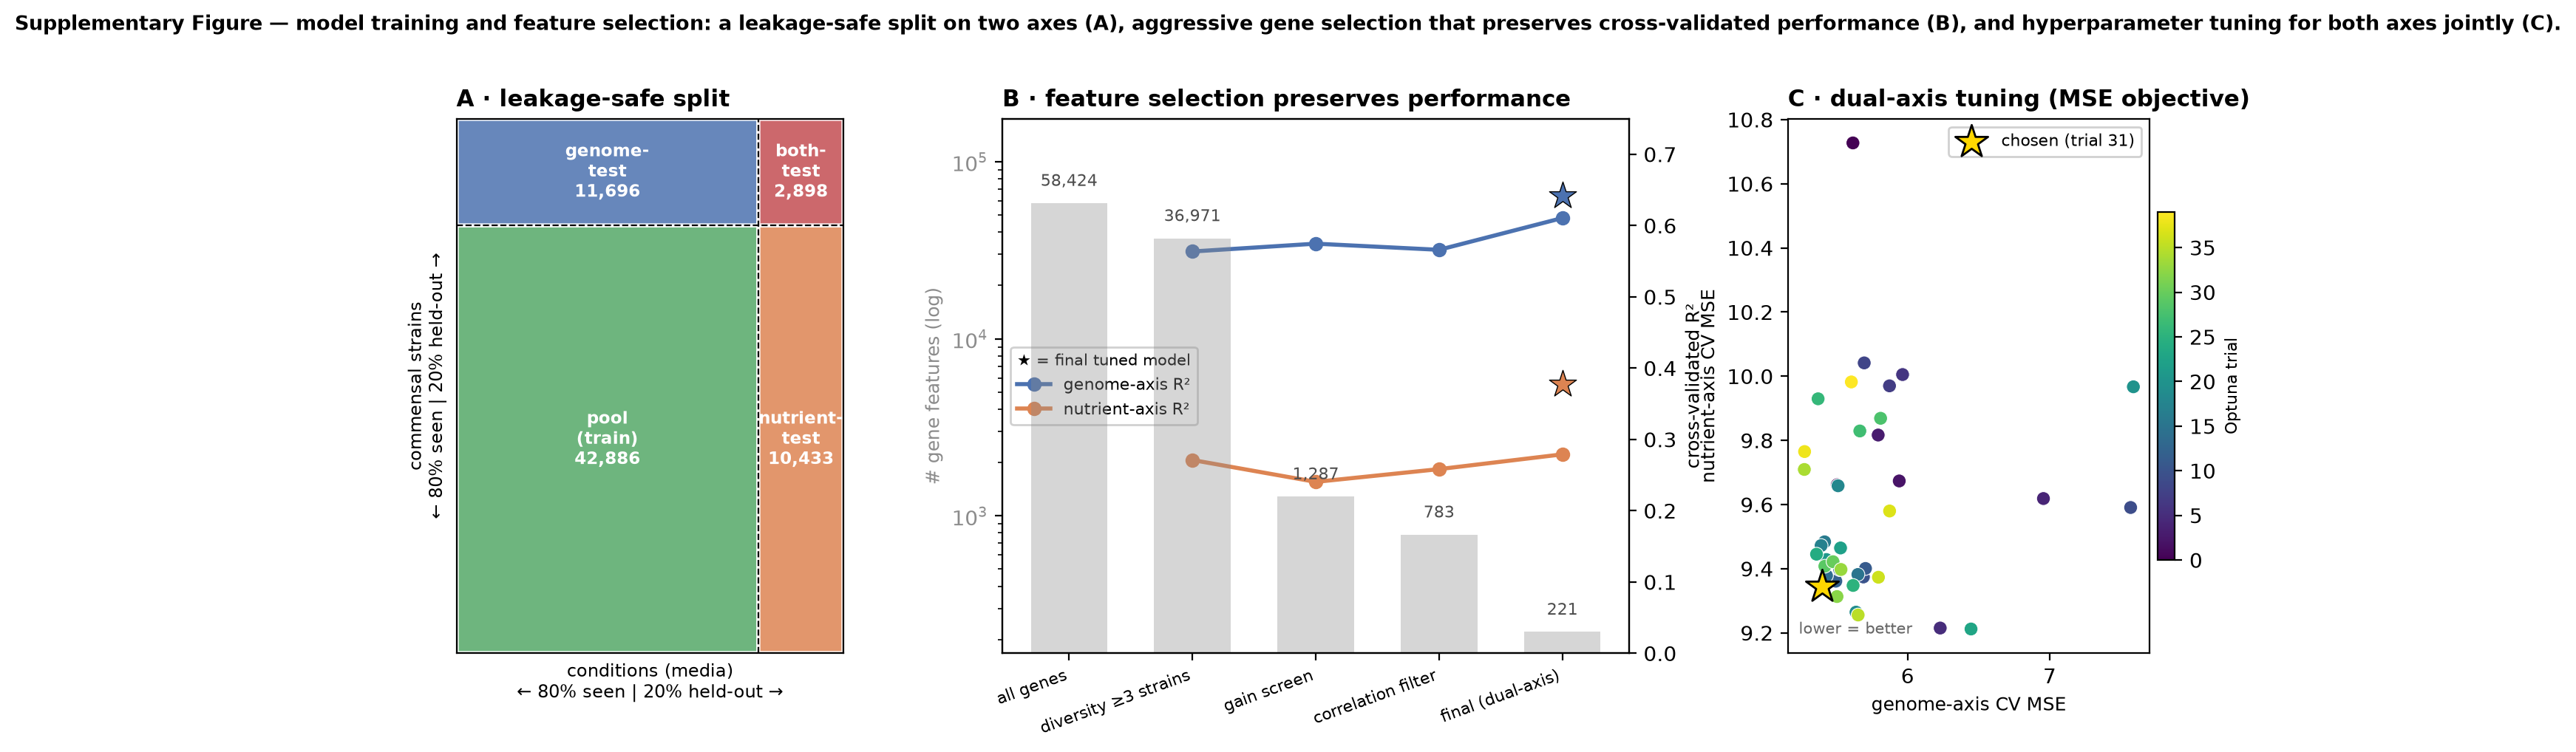

In [ ]:
# Supplementary Figure: training & feature selection (A split · B selection funnel + CV-R² · C dual-axis tuning)
import os
if not os.path.exists('paper_figures/figS_training_cache/funnel.json'):
    exec(open('paper_figures/compute_figS_training.py').read())   # reconstruct stages + dual-axis CV (~5-12 min)
exec(open('paper_figures/make_figS_training.py').read())
from IPython.display import Image, display
display(Image('paper_figures/figS_training_featureselection.png'))

## Supplementary Figure — SHAP importances are reproducible
Bootstrap importance stability (mean|SHAP| ± std, split-half rank ρ; **A**), recovery of the top-ranked set in every bootstrap (**B**), and agreement with an independent dual-axis permutation-importance measure (**C**). Reproduces the Step-4.4 bootstrap on the all-data model (`robust_model_all_data.json`) and reads `dual_axis_importance.csv`. Compute `paper_figures/compute_figS_shap_repro.py` (~2-4 min, GPU) → `paper_figures/figS_shap_repro_cache/`; render `paper_figures/make_figS_shap_repro.py` → `paper_figures/figS_shap_reproducibility.{pdf,png}`.

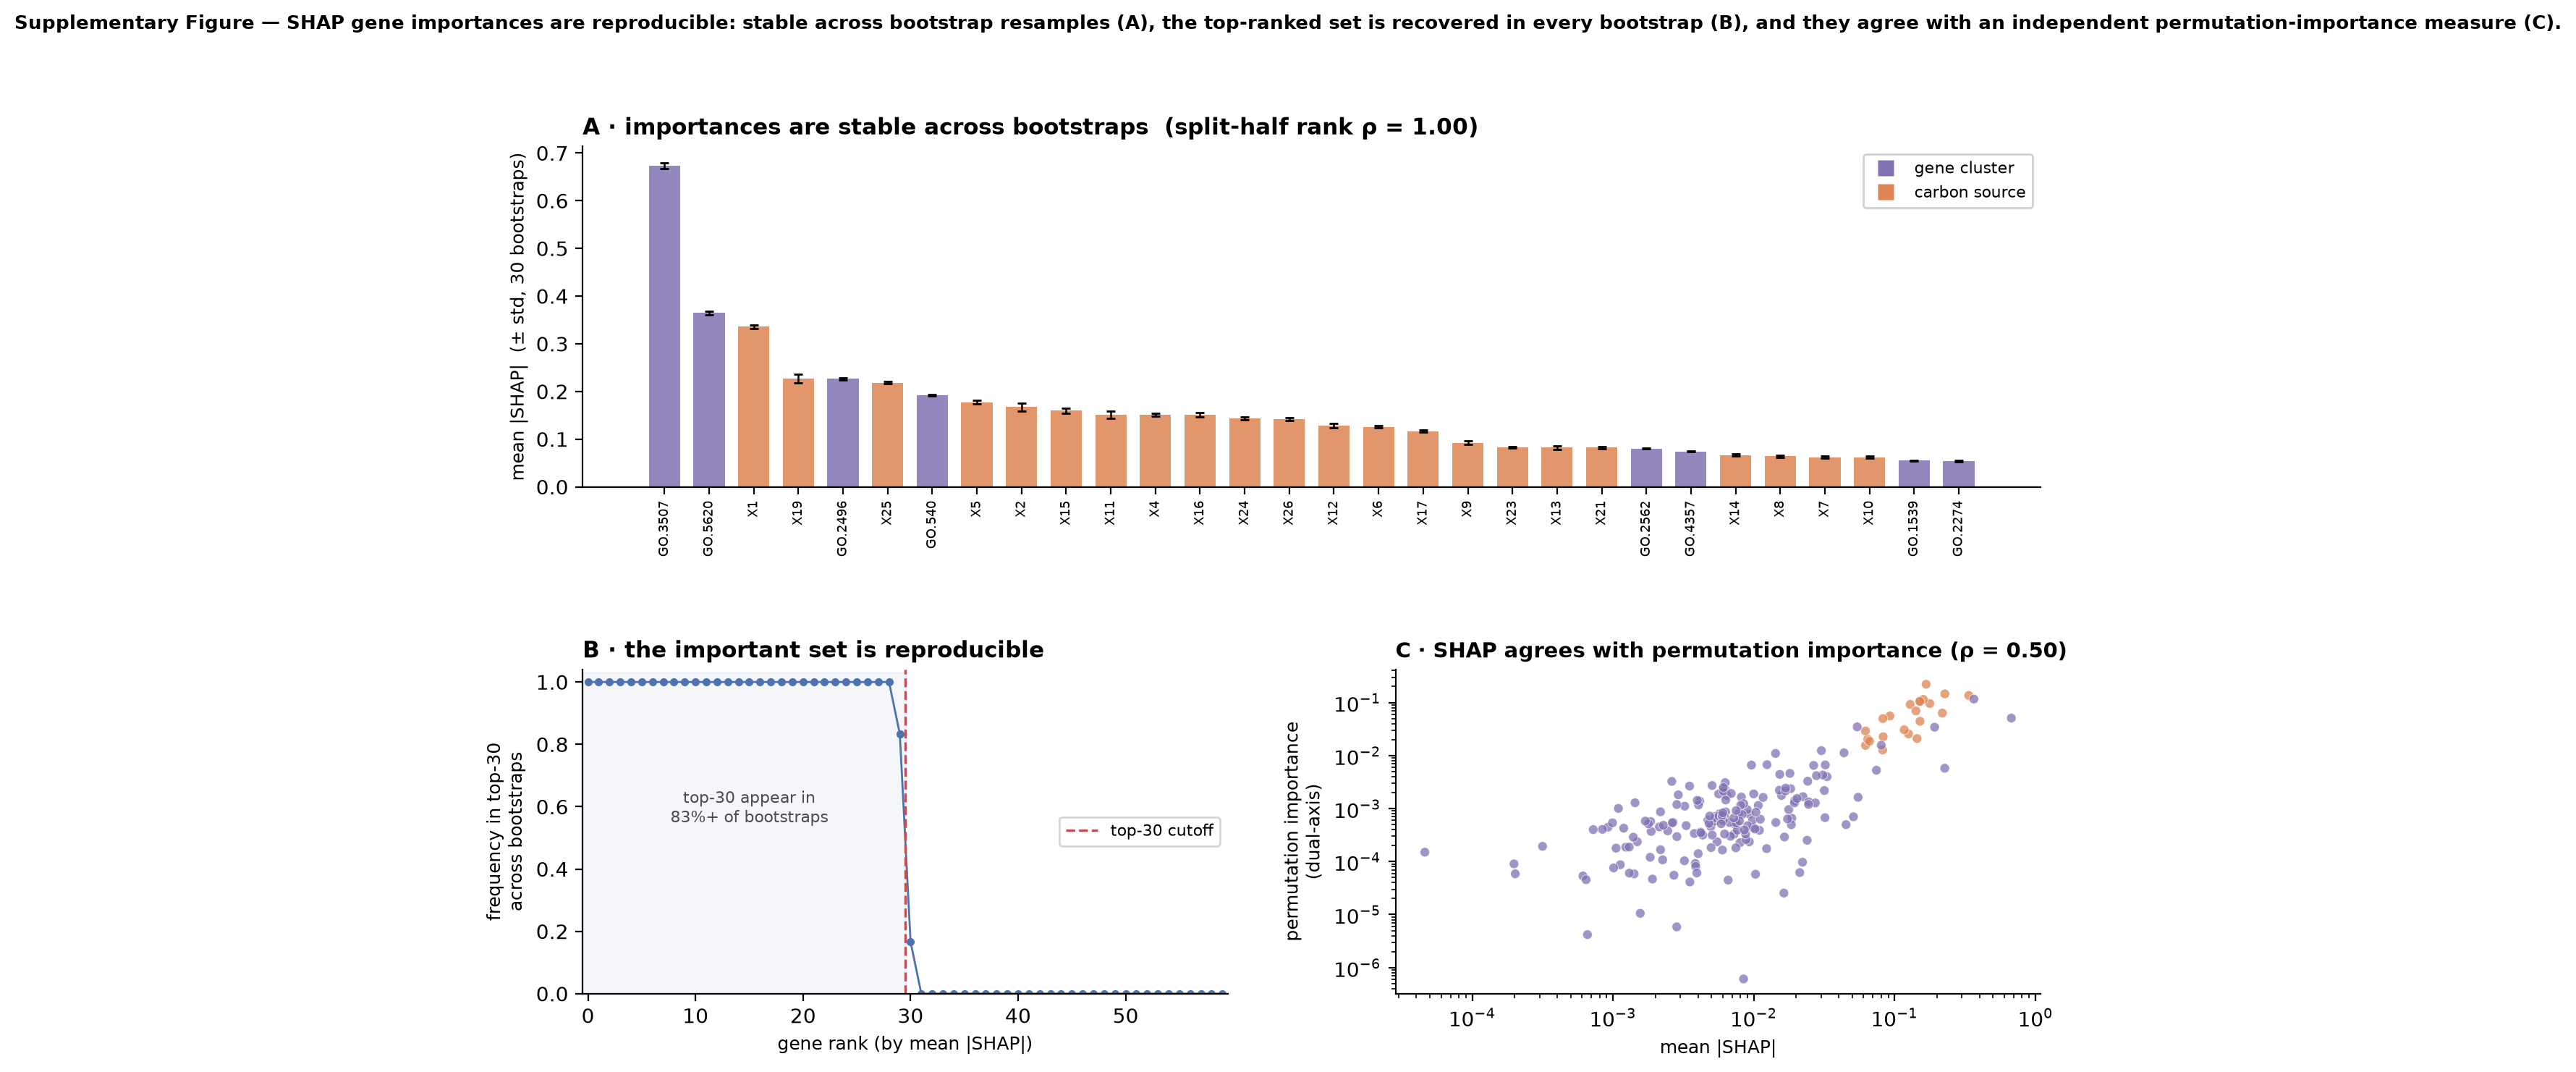

In [ ]:
# Supplementary Figure: SHAP importances are reproducible (A stability · B top-k · C vs permutation)
import os
if not os.path.exists('paper_figures/figS_shap_repro_cache/repro.json'):
    exec(open('paper_figures/compute_figS_shap_repro.py').read())   # 30-bootstrap SHAP on all-data model (~2-4 min)
exec(open('paper_figures/make_figS_shap_repro.py').read())
from IPython.display import Image, display
display(Image('paper_figures/figS_shap_reproducibility.png'))

## Supplementary Figure — predicted vs measured on each held-out block
The pool model predicting the three held-out sets: unseen genomes (**A**), unseen media (**B**), unseen genomes+media (**C**), and a summary (**D**) showing that the lower R² on media is largely a variance-denominator effect (similar RMSE, different Var z), not larger error. Compute `paper_figures/compute_figS_predictions.py` (predicts the blocks with `robust_model.json`) → `figS_predictions_cache/`; render `paper_figures/make_figS_predictions.py` → `paper_figures/figS_pred_vs_measured_axes.{pdf,png}`.

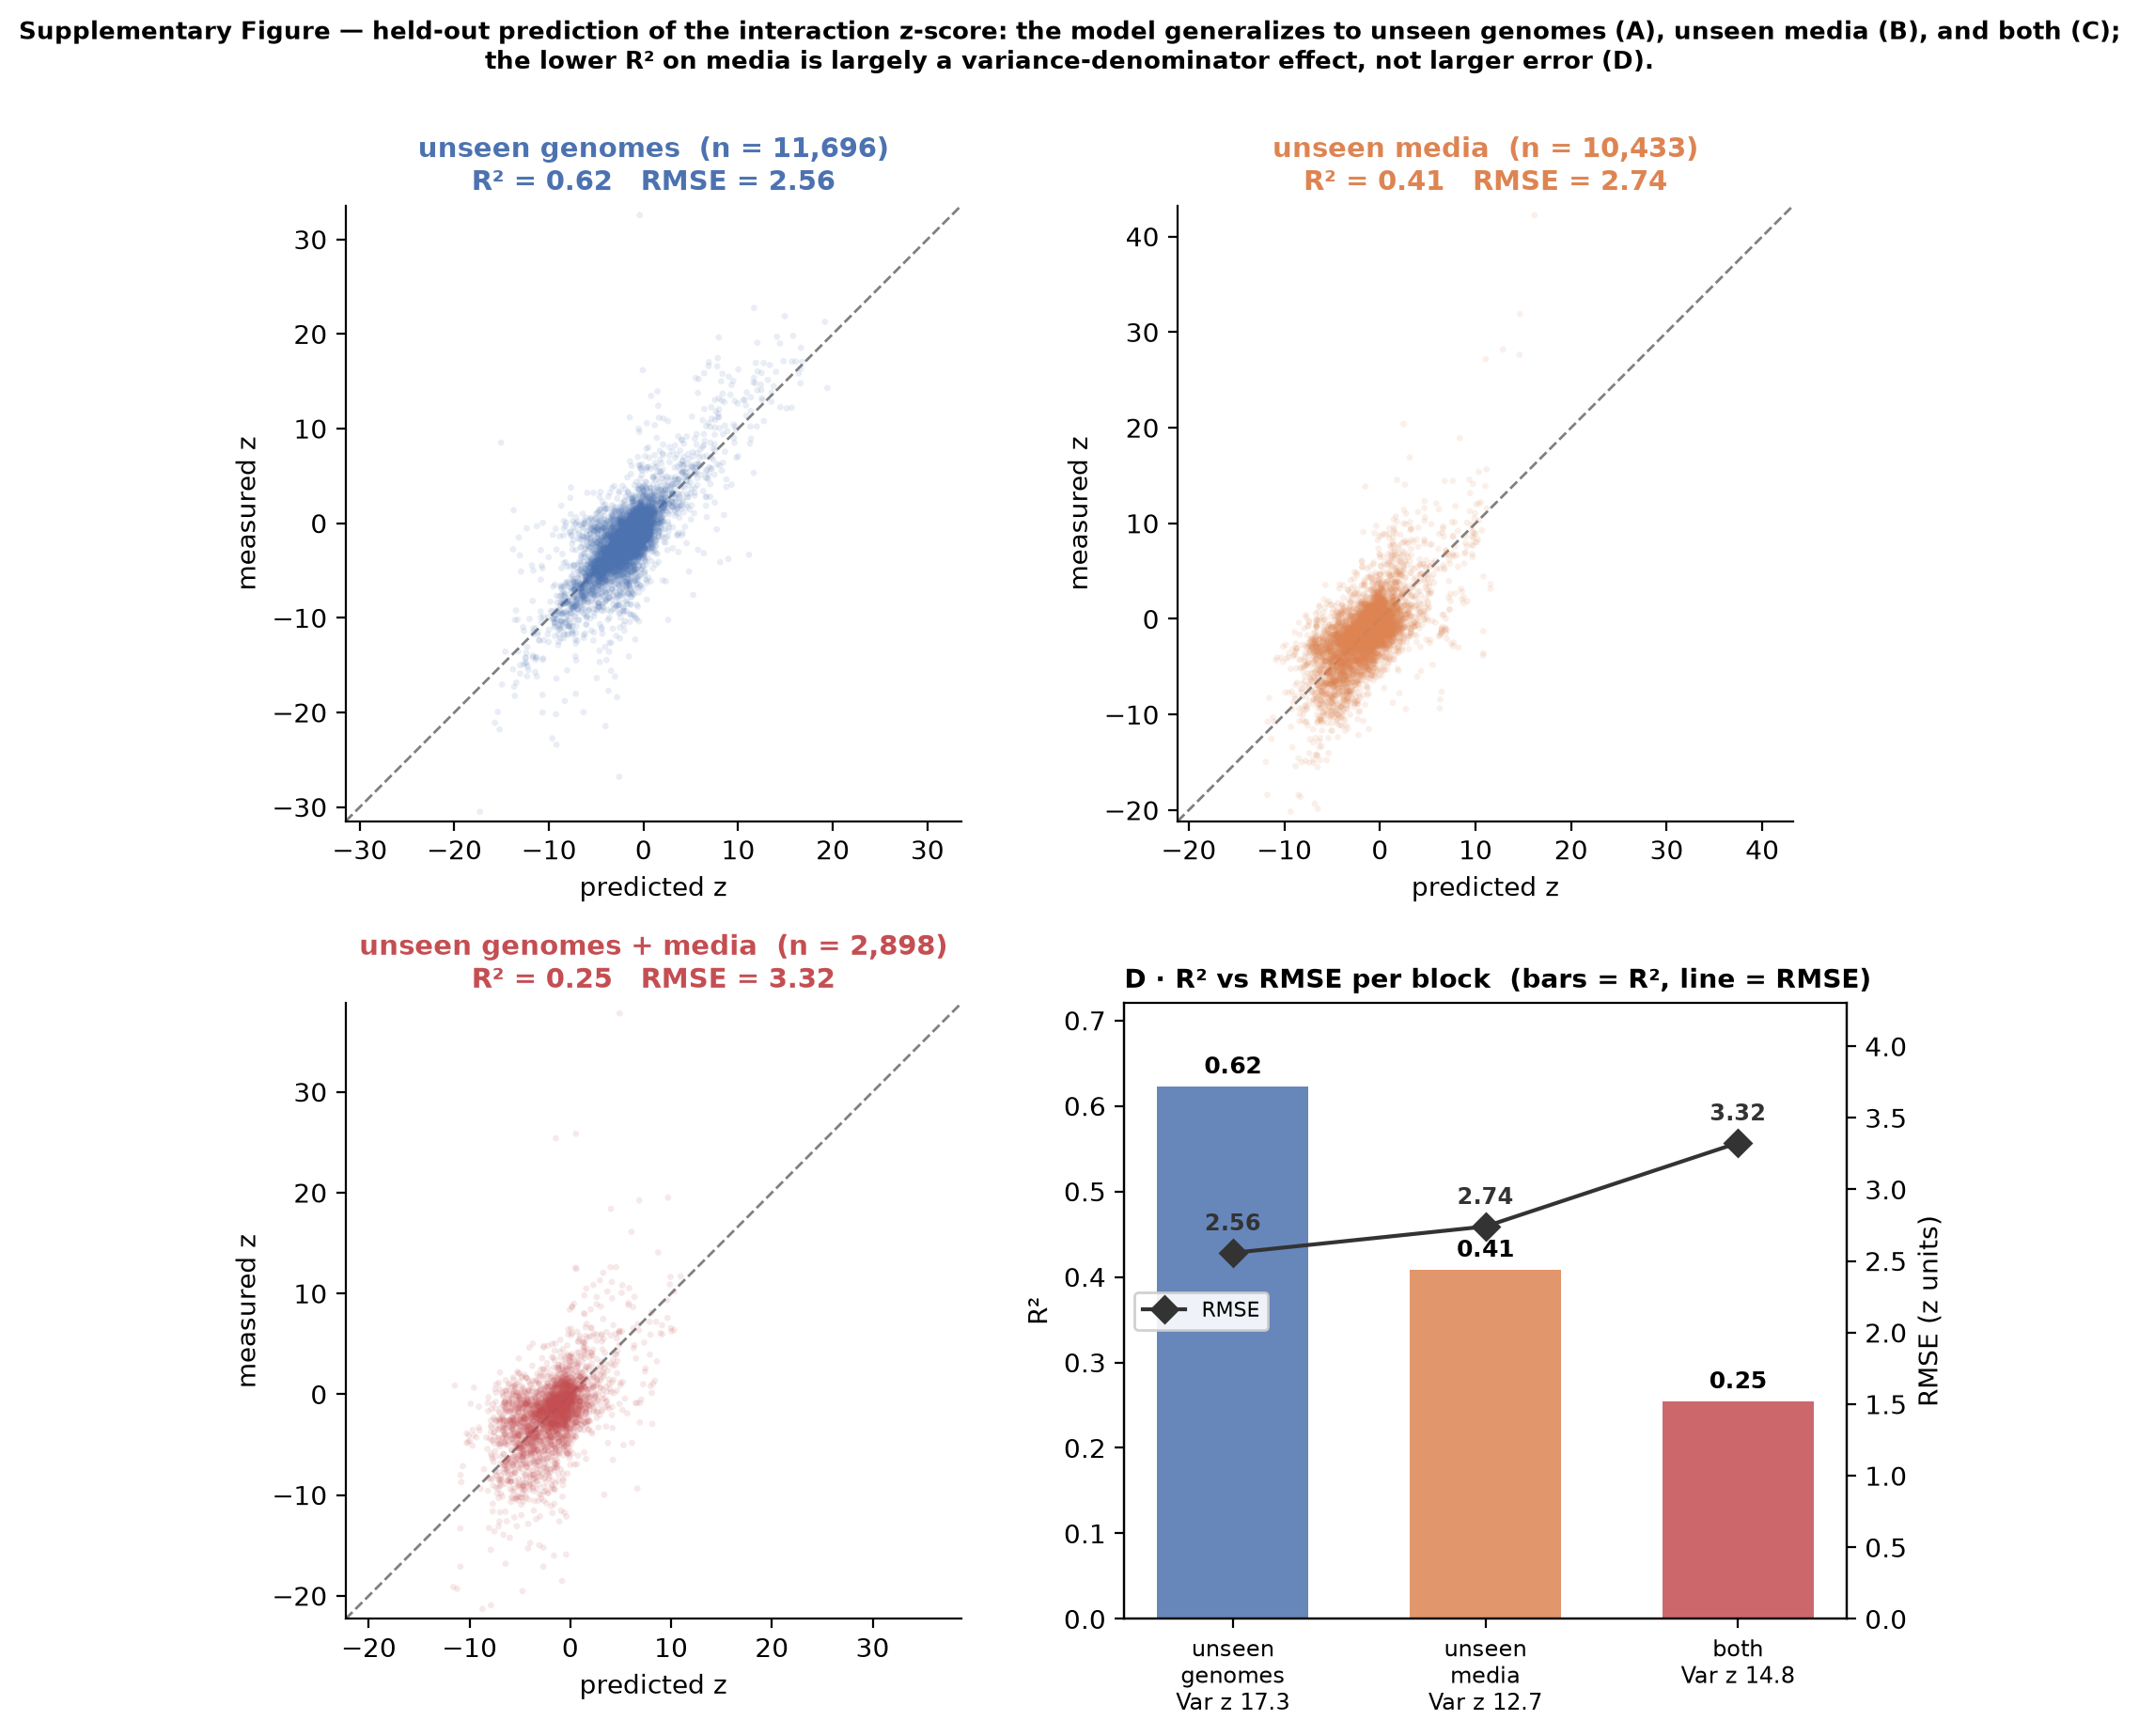

In [ ]:
# Supplementary Figure: predicted vs measured per held-out block (A genomes · B media · C both · D R²-vs-RMSE)
import os
if not os.path.exists('paper_figures/figS_predictions_cache/predictions.json'):
    exec(open('paper_figures/compute_figS_predictions.py').read())
exec(open('paper_figures/make_figS_predictions.py').read())
from IPython.display import Image, display
display(Image('paper_figures/figS_pred_vs_measured_axes.png'))